In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from src.utils import read_obs, save_figure

/opt/conda/lib/python3.12/importlib/__init__.py:90: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  return _bootstrap._gcd_import(name[level:], package, level)


In [3]:
obs = read_obs("/root/capsule/data/filtered_adata/CaH_final_nuclei.2025-12-29.h5ad")
cell_bool = obs.groupby("Donor ID")["Supertype"].value_counts().unstack("Supertype").apply(lambda x: np.any(x < 10))
cells_to_remove= cell_bool[cell_bool].index.str.replace(" ", "_") 

/tmp/ipykernel_48601/3051182257.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_bool = obs.groupby("Donor ID")["Supertype"].value_counts().unstack("Supertype").apply(lambda x: np.any(x < 10))


In [4]:
at8_df = pd.read_csv("/data/DEG_Supplemental_Tables/Supplemental Table 5.csv", index_col = 0)
sixE10_df = pd.read_csv("/data/DEG_Supplemental_Tables/Supplemental Table 6.csv", index_col = 0)
adnc_df = pd.read_csv("/root/capsule/data/SEAAD_CaH_ADNC_Nebula_Results/seaad_cah_nebula_adnc_codes.csv",)
adnc_df.index = (adnc_df['Supertype'] + "_" + adnc_df["index"]).str.replace(" ", "_")
braak_df = pd.read_csv("/root/capsule/data/SEAAD_CaH_Braak_Nebula_Results/seaad_cah_nebula_braak_codes.csv", )
braak_df.index = (braak_df['Supertype'] + "_" + braak_df['index']).str.replace(" ", "_")
thal_df = pd.read_csv("/root/capsule/data/SEAAD_CaH_Thal_Nebula_Results/seaad_cah_nebula_thal_codes.csv",)
thal_df.index = (thal_df['Supertype'] + "_" + thal_df['index']).str.replace(" ", "_")

In [5]:
df_dict = {"CPS_AT8":at8_df, "CPS_6e10":sixE10_df, "ADNC_codes":adnc_df, "Braak_codes":braak_df, "Thal_codes":thal_df}

In [6]:
def mask_high_var(df, covaraiate):
    return df.apply(lambda x: x[f"logFC_{covariate}"] if x[f"se_{covariate}"] < 20 else np.nan, axis = 1)

def get_covariates(df, prefix = "se_"):
    prefix_df = df.loc[:,[col.startswith(prefix) for col in df.columns]]
    return prefix_df.columns.map(lambda x: x.removeprefix(prefix)).tolist()

In [7]:
for path, df in df_dict.items():
    for covariate in get_covariates(df):
        df_dict[path][f"logFC_{covariate}"] = mask_high_var(df, covariate)
    df_dict[path]["Significant"] = (df[f'logFC_{path}'].abs() > 0.5) & (df[f'fdr_p_{path}'] < 0.1)

In [8]:
for path, df in df_dict.items():
    df_dict[path]['Regulation'] = (df_dict[path][f'logFC_{path}'] > 0).replace({True:"Up", False:"Down"})

In [9]:
at8_significant = df_dict["CPS_AT8"][df_dict["CPS_AT8"]["Significant"]].index
sixE10_significant = df_dict["CPS_6e10"][df_dict["CPS_6e10"]["Significant"]].index

In [10]:
both_idx = at8_significant.intersection(sixE10_significant)
at8_idx = at8_significant.difference(sixE10_significant)
sixE10_idx = sixE10_significant.difference(at8_significant)

In [11]:
both_count = at8_df.loc[both_idx].groupby(["cell_type", "Regulation"])["var_name"].count().reset_index()
both_count['path'] = "Both"

at8_count =  at8_df.loc[at8_idx].groupby(["cell_type", "Regulation"])["var_name"].count().reset_index()
at8_count['path'] = r"$CPS_{AT8}$"

sixE10_count = sixE10_df.loc[sixE10_idx].groupby(["cell_type", "Regulation"])['var_name'].count().reset_index()
sixE10_count['path'] = r"$CPS_{6E10}$"

count_df = pd.concat([both_count, at8_count, sixE10_count])

In [12]:
count_df = count_df[~count_df['cell_type'].isin(cells_to_remove)].sort_values("cell_type")

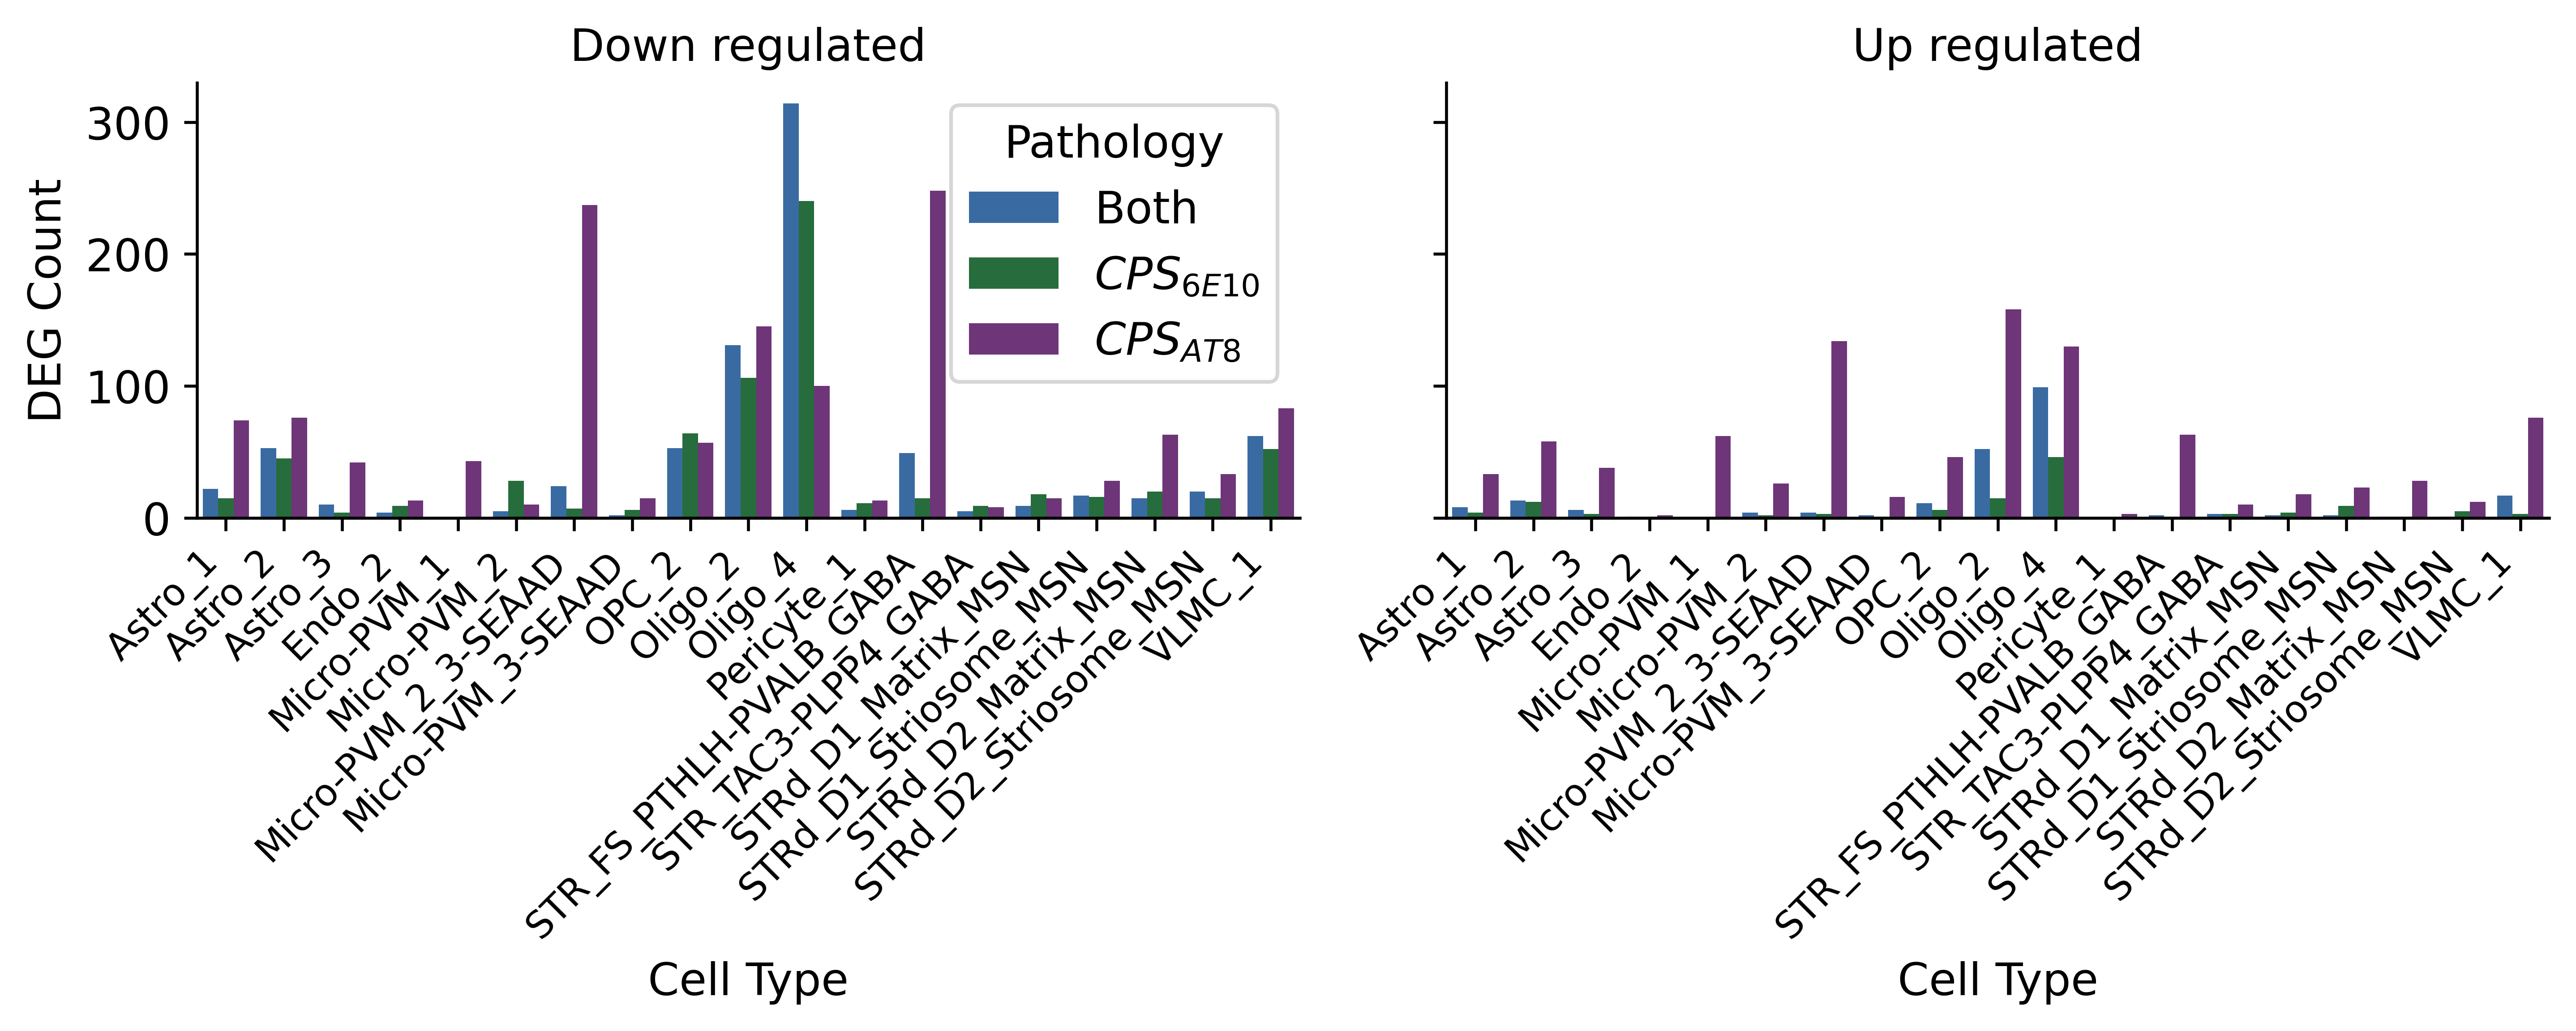

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

path = ["Both", r"$CPS_{AT8}$", r"$CPS_{6E10}$"]
colors = ['#276AB3', "#762a83", "#1b7837"]
palette = dict(zip(path, colors))
with plt.rc_context({"font.size": 12, "figure.figsize":(15, 5*4.141), 'figure.dpi':600}):
    g = sns.catplot(
        data=count_df,
        x="cell_type",
        y = "var_name",
        hue="path",
        col="Regulation",
        kind="bar",
        height=4,
        aspect=1.2,
        col_wrap=3,       # wrap columns if you have many cell types
        palette=palette,
        legend_out = False
    )

    g.set_xticklabels(rotation=45, ha="right", fontsize = 10)
    g.set_axis_labels("Cell Type", "DEG Count")
    g.set_titles("{col_name} regulated")
    g._legend.set_title("Pathology")
    plt.tight_layout()
    plt.savefig("/scratch/Figure3F.svg")
    # save_figure(g, "/scratch/Figure3F", dpi = 600)
    plt.show()

In [14]:
df_dict['CPS_AT8']

,logFC_(Intercept),logFC_Age_at_Death_binned_codes,logFC_Sex_codes,logFC_method10xV3.1_HT,logFC_APOE4_Status_codes,logFC_CPS_AT8,se_(Intercept),se_Age_at_Death_binned_codes,se_Sex_codes,se_method10xV3.1_HT,...,var_name,var_index,fdr_p_Age_at_Death_binned_codes,fdr_p_Sex_codes,fdr_p_method10xV3.1_HT,fdr_p_APOE4_Status_codes,fdr_p_CPS_AT8,cell_type,Significant,Regulation
Micro-PVM_2_1-SEAAD_AL627309.1,NaN,0.260529,-0.517282,NaN,-0.450044,3.037225,73.604779,0.673275,0.521646,1200.317575,...,AL627309.1,AL627309.1,0.973411,0.897785,9.999188e-01,0.972881,0.965773,Micro-PVM_2_1-SEAAD,False,Up
Micro-PVM_2_1-SEAAD_AL627309.5,NaN,-1.494190,0.655691,NaN,-1.466823,-0.480798,56.971883,1.212134,0.956395,929.067135,...,AL627309.5,AL627309.5,0.881053,0.943570,9.999188e-01,0.940409,0.992645,Micro-PVM_2_1-SEAAD,False,Down
Micro-PVM_2_1-SEAAD_LINC01409,NaN,-0.870350,0.346638,NaN,-0.755130,-0.511939,76.806784,0.497746,0.380498,1252.539610,...,LINC01409,LINC01409,0.859183,0.908287,9.999188e-01,0.938180,0.965773,Micro-PVM_2_1-SEAAD,False,Down
Micro-PVM_2_1-SEAAD_LINC01128,-10.847169,0.306247,1.073078,-0.003421,-0.289869,-0.548653,0.170204,0.616174,0.477999,0.838496,...,LINC01128,LINC01128,0.958811,0.719170,9.999188e-01,0.989485,0.970952,Micro-PVM_2_1-SEAAD,False,Down
Micro-PVM_2_1-SEAAD_LINC00115,NaN,-0.383347,-0.267463,NaN,-0.382461,-0.716821,59.583069,1.471836,1.161032,971.635739,...,LINC00115,LINC00115,0.986199,0.999873,9.999188e-01,0.999980,0.993217,Micro-PVM_2_1-SEAAD,False,Down
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
STRd_D1D2_Hybrid_MSN_MAFIP,-12.286099,0.010987,-0.621993,0.702706,0.276162,-0.462454,0.104664,0.345698,0.229667,0.069419,...,MAFIP,MAFIP,0.997764,0.616476,2.069956e-22,0.995286,0.866995,STRd_D1D2_Hybrid_MSN,False,Down
STRd_D1D2_Hybrid_MSN_AC011043.1,-13.659372,-0.219846,0.739584,-0.379920,0.282818,-0.863205,0.221327,0.822834,0.540731,0.098420,...,AC011043.1,AC011043.1,0.983984,0.768996,5.914875e-04,0.995286,0.907766,STRd_D1D2_Hybrid_MSN,False,Down
STRd_D1D2_Hybrid_MSN_AL592183.1,-9.965781,0.125143,-0.021648,-0.162272,0.116245,0.295144,0.099144,0.350758,0.221124,0.022742,...,AL592183.1,AL592183.1,0.978292,0.985730,1.774590e-11,0.995286,0.927066,STRd_D1D2_Hybrid_MSN,False,Up
STRd_D1D2_Hybrid_MSN_AC240274.1,-12.778401,0.171281,-0.287994,-0.050714,0.115009,-0.125512,0.059723,0.192822,0.131870,0.086450,...,AC240274.1,AC240274.1,0.919784,0.715916,6.903279e-01,0.995286,0.947868,STRd_D1D2_Hybrid_MSN,False,Down


In [15]:
sig_gene_fs = df_dict["CPS_AT8"][(df_dict["CPS_AT8"]["Significant"]) & (df_dict['CPS_AT8']["cell_type"] == "STR_FS_PTHLH-PVALB_GABA")]

In [16]:
sig_gene_fs[['logFC_CPS_AT8', 'var_name']].to_csv()

',logFC_CPS_AT8,var_name\nSTR_FS_PTHLH-PVALB_GABA_HES4,-1.466221932195841,HES4\nSTR_FS_PTHLH-PVALB_GABA_ISG15,-0.9791408235128344,ISG15\nSTR_FS_PTHLH-PVALB_GABA_SCNN1D,-0.613232419523004,SCNN1D\nSTR_FS_PTHLH-PVALB_GABA_MEGF6,-0.9277901580875922,MEGF6\nSTR_FS_PTHLH-PVALB_GABA_TMEM51,-1.235318623712096,TMEM51\nSTR_FS_PTHLH-PVALB_GABA_CELA2A,-1.046714017492489,CELA2A\nSTR_FS_PTHLH-PVALB_GABA_TRNP1,-0.6241175770066528,TRNP1\nSTR_FS_PTHLH-PVALB_GABA_MAP3K6,-0.6068043905241384,MAP3K6\nSTR_FS_PTHLH-PVALB_GABA_ELOVL1,-0.5524053537989552,ELOVL1\nSTR_FS_PTHLH-PVALB_GABA_PIK3R3,0.5905799987534683,PIK3R3\nSTR_FS_PTHLH-PVALB_GABA_CYP4A22,-1.133113034950497,CYP4A22\nSTR_FS_PTHLH-PVALB_GABA_ZYG11A,-1.101704814100223,ZYG11A\nSTR_FS_PTHLH-PVALB_GABA_LRP8,-0.7531604215574812,LRP8\nSTR_FS_PTHLH-PVALB_GABA_AK5,-0.5770361414601137,AK5\nSTR_FS_PTHLH-PVALB_GABA_LMO4,-0.7010293001901003,LMO4\nSTR_FS_PTHLH-PVALB_GABA_LINC01676,-0.6378343848004927,LINC01676\nSTR_FS_PTHLH-PVALB_GABA_RBM15-AS1,0.5966591591307004,

In [17]:
genes = ["PRDX3", "HSPD1", "ECHS1", "ECH1", "SLC25A11", "SLC25A29", "RHOT2", "GFER", "CKMT1A", "CKMT1B"]
sig_gene_fs[sig_gene_fs.var_name.isin(genes)]

,logFC_(Intercept),logFC_Age_at_Death_binned_codes,logFC_Sex_codes,logFC_method10xV3.1_HT,logFC_APOE4_Status_codes,logFC_CPS_AT8,se_(Intercept),se_Age_at_Death_binned_codes,se_Sex_codes,se_method10xV3.1_HT,...,var_name,var_index,fdr_p_Age_at_Death_binned_codes,fdr_p_Sex_codes,fdr_p_method10xV3.1_HT,fdr_p_APOE4_Status_codes,fdr_p_CPS_AT8,cell_type,Significant,Regulation
STR_FS_PTHLH-PVALB_GABA_HSPD1,-10.050059,-0.451644,-0.016308,-0.068302,0.079068,-0.616892,0.041773,0.132655,0.091997,0.022862,...,HSPD1,HSPD1,0.082580,0.999971,8.537302e-03,0.893008,0.068722,STR_FS_PTHLH-PVALB_GABA,True,Down
STR_FS_PTHLH-PVALB_GABA_PRDX3,-11.390477,-0.221405,-0.018744,-0.166208,0.165369,-0.678013,0.046960,0.150098,0.102616,0.040533,...,PRDX3,PRDX3,0.487552,0.999971,1.867188e-04,0.868308,0.083466,STR_FS_PTHLH-PVALB_GABA,True,Down
STR_FS_PTHLH-PVALB_GABA_ECHS1,-11.352359,-0.116642,-0.005906,0.223081,0.114021,-0.559838,0.040356,0.127390,0.087542,0.044832,...,ECHS1,ECHS1,0.705139,0.999971,4.007741e-06,0.872576,0.095807,STR_FS_PTHLH-PVALB_GABA,True,Down
STR_FS_PTHLH-PVALB_GABA_SLC25A29,-10.749310,-0.048147,-0.000655,0.264946,0.157681,-0.656377,0.039459,0.132939,0.088179,0.035842,...,SLC25A29,SLC25A29,0.898800,0.999971,1.882036e-12,0.868308,0.062834,STR_FS_PTHLH-PVALB_GABA,True,Down
STR_FS_PTHLH-PVALB_GABA_CKMT1B,-10.798404,-0.018047,-0.082934,0.068652,0.193820,-1.048473,0.048420,0.162077,0.110035,0.032587,...,CKMT1B,CKMT1B,0.971608,0.999971,7.577762e-02,0.868308,0.009066,STR_FS_PTHLH-PVALB_GABA,True,Down
STR_FS_PTHLH-PVALB_GABA_CKMT1A,-11.801855,-0.152491,-0.090543,-0.041696,0.087123,-0.695452,0.041608,0.134388,0.093423,0.048646,...,CKMT1A,CKMT1A,0.618672,0.999971,5.258348e-01,0.888117,0.047173,STR_FS_PTHLH-PVALB_GABA,True,Down
STR_FS_PTHLH-PVALB_GABA_RHOT2,-10.838036,0.032296,-0.064673,0.612067,0.137949,-0.562592,0.038882,0.125456,0.086457,0.038444,...,RHOT2,RHOT2,0.933303,0.999971,4.740697e-55,0.868308,0.097778,STR_FS_PTHLH-PVALB_GABA,True,Down
STR_FS_PTHLH-PVALB_GABA_GFER,-12.894971,-0.106446,0.039199,0.346552,0.062714,-0.606778,0.042261,0.136252,0.092766,0.096872,...,GFER,GFER,0.756388,0.999971,1.312708e-03,0.917150,0.082115,STR_FS_PTHLH-PVALB_GABA,True,Down
STR_FS_PTHLH-PVALB_GABA_SLC25A11,-11.817329,-0.442885,0.033753,0.061737,0.238026,-0.810361,0.054137,0.168558,0.116855,0.054407,...,SLC25A11,SLC25A11,0.190162,0.999971,3.819373e-01,0.868308,0.048641,STR_FS_PTHLH-PVALB_GABA,True,Down
STR_FS_PTHLH-PVALB_GABA_ECH1,-11.647424,-0.033377,-0.001003,-0.156931,0.141617,-0.528544,0.037011,0.116892,0.080417,0.045745,...,ECH1,ECH1,0.924690,0.999971,2.154065e-03,0.868308,0.091322,STR_FS_PTHLH-PVALB_GABA,True,Down


In [18]:
genes = ["CHRNA4", "DRD2"]
sig_gene_fs[sig_gene_fs.var_name.isin(genes)]

,logFC_(Intercept),logFC_Age_at_Death_binned_codes,logFC_Sex_codes,logFC_method10xV3.1_HT,logFC_APOE4_Status_codes,logFC_CPS_AT8,se_(Intercept),se_Age_at_Death_binned_codes,se_Sex_codes,se_method10xV3.1_HT,...,var_name,var_index,fdr_p_Age_at_Death_binned_codes,fdr_p_Sex_codes,fdr_p_method10xV3.1_HT,fdr_p_APOE4_Status_codes,fdr_p_CPS_AT8,cell_type,Significant,Regulation
STR_FS_PTHLH-PVALB_GABA_DRD2,-10.260701,-0.014261,0.216018,0.309889,-0.125354,0.607670,0.039124,0.124781,0.086005,0.030913,...,DRD2,DRD2,0.970711,0.766658,3.215062e-22,0.868461,0.065074,STR_FS_PTHLH-PVALB_GABA,True,Up
STR_FS_PTHLH-PVALB_GABA_CHRNA4,-13.391594,0.150124,-0.100542,0.260227,0.209952,-1.111116,0.055928,0.181895,0.123180,0.124799,...,CHRNA4,CHRNA4,0.739576,0.999971,7.920606e-02,0.868308,0.012635,STR_FS_PTHLH-PVALB_GABA,True,Down


In [19]:
genes = ["SYN1", "CALM2", "RBA3A", "RAB4A", "TUBB4", "SYN3", "SYNGR3", "AMPH", "NRGN", "RAB4B", "TUBB4"]
sig_gene_fs[sig_gene_fs.var_name.isin(genes)]

,logFC_(Intercept),logFC_Age_at_Death_binned_codes,logFC_Sex_codes,logFC_method10xV3.1_HT,logFC_APOE4_Status_codes,logFC_CPS_AT8,se_(Intercept),se_Age_at_Death_binned_codes,se_Sex_codes,se_method10xV3.1_HT,...,var_name,var_index,fdr_p_Age_at_Death_binned_codes,fdr_p_Sex_codes,fdr_p_method10xV3.1_HT,fdr_p_APOE4_Status_codes,fdr_p_CPS_AT8,cell_type,Significant,Regulation


In [27]:
sig_gene_fs[sig_gene_fs.var_name.str.startswith("NPTX2")]

,logFC_(Intercept),logFC_Age_at_Death_binned_codes,logFC_Sex_codes,logFC_method10xV3.1_HT,logFC_APOE4_Status_codes,logFC_CPS_AT8,se_(Intercept),se_Age_at_Death_binned_codes,se_Sex_codes,se_method10xV3.1_HT,...,var_name,var_index,fdr_p_Age_at_Death_binned_codes,fdr_p_Sex_codes,fdr_p_method10xV3.1_HT,fdr_p_APOE4_Status_codes,fdr_p_CPS_AT8,cell_type,Significant,Regulation
STR_FS_PTHLH-PVALB_GABA_NPTX2,-12.667167,0.326258,0.325469,-0.245547,0.44211,-1.839097,0.108655,0.371941,0.235849,0.091603,...,NPTX2,NPTX2,0.720433,0.999971,0.019807,0.868308,0.083444,STR_FS_PTHLH-PVALB_GABA,True,Down


In [28]:
sig_gene_fs[sig_gene_fs.var_name.str.startswith("GJD2")]

,logFC_(Intercept),logFC_Age_at_Death_binned_codes,logFC_Sex_codes,logFC_method10xV3.1_HT,logFC_APOE4_Status_codes,logFC_CPS_AT8,se_(Intercept),se_Age_at_Death_binned_codes,se_Sex_codes,se_method10xV3.1_HT,...,var_name,var_index,fdr_p_Age_at_Death_binned_codes,fdr_p_Sex_codes,fdr_p_method10xV3.1_HT,fdr_p_APOE4_Status_codes,fdr_p_CPS_AT8,cell_type,Significant,Regulation
STR_FS_PTHLH-PVALB_GABA_GJD2,-12.668737,-0.131854,-0.22072,0.024176,0.076794,-0.726617,0.04912,0.160508,0.10812,0.075787,...,GJD2,GJD2,0.741162,0.999971,0.828836,0.91483,0.090332,STR_FS_PTHLH-PVALB_GABA,True,Down


In [29]:
sig_gene_fs[sig_gene_fs.var_name.str.startswith("ESRRA")]

,logFC_(Intercept),logFC_Age_at_Death_binned_codes,logFC_Sex_codes,logFC_method10xV3.1_HT,logFC_APOE4_Status_codes,logFC_CPS_AT8,se_(Intercept),se_Age_at_Death_binned_codes,se_Sex_codes,se_method10xV3.1_HT,...,var_name,var_index,fdr_p_Age_at_Death_binned_codes,fdr_p_Sex_codes,fdr_p_method10xV3.1_HT,fdr_p_APOE4_Status_codes,fdr_p_CPS_AT8,cell_type,Significant,Regulation
STR_FS_PTHLH-PVALB_GABA_ESRRA,-10.728415,-0.190884,-0.064307,0.135581,0.147427,-0.572779,0.035983,0.117729,0.079103,0.033364,...,ESRRA,ESRRA,0.436865,0.999971,0.000216,0.868308,0.049326,STR_FS_PTHLH-PVALB_GABA,True,Down


In [31]:
sig_gene_fs[sig_gene_fs.var_name.str.startswith("DMD")]

,logFC_(Intercept),logFC_Age_at_Death_binned_codes,logFC_Sex_codes,logFC_method10xV3.1_HT,logFC_APOE4_Status_codes,logFC_CPS_AT8,se_(Intercept),se_Age_at_Death_binned_codes,se_Sex_codes,se_method10xV3.1_HT,...,var_name,var_index,fdr_p_Age_at_Death_binned_codes,fdr_p_Sex_codes,fdr_p_method10xV3.1_HT,fdr_p_APOE4_Status_codes,fdr_p_CPS_AT8,cell_type,Significant,Regulation
STR_FS_PTHLH-PVALB_GABA_DMD,-9.081959,-0.383121,0.079,0.184086,0.016822,-0.949433,0.059664,0.199182,0.135374,0.048137,...,DMD,DMD,0.336628,0.999971,0.000542,0.985445,0.078703,STR_FS_PTHLH-PVALB_GABA,True,Down


# Supplemental Figure

In [13]:
comparison_dict = {}
index_set = set()
for path, df in df_dict.items():
    values = df_dict[path][f'logFC_{path}'].dropna()
    if not index_set:
        index_set = set(values.index) | index_set
    else:
        index_set = set(values.index) & index_set

index_list = list(index_set)
comparison_dict = {fr"$\beta_{{{path.replace("_", "\_")}}}$":df.loc[index_list, f'logFC_{path}'] for path, df in df_dict.items()}
comparison_df = pd.DataFrame(comparison_dict)
comparison_df["gene"] = comparison_df.index.map(lambda x: x.split("_")[-1])
comparison_df["Cell Type"] = comparison_df.index.map(lambda x: "_".join(x.split("_")[:-1]))
comparison_df

<>:11: SyntaxWarning: invalid escape sequence '\_'
<>:11: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_758931/2642495931.py:11: SyntaxWarning: invalid escape sequence '\_'
  comparison_dict = {fr"$\beta_{{{path.replace("_", "\_")}}}$":df.loc[index_list, f'logFC_{path}'] for path, df in df_dict.items()}


,$\beta_{CPS\_AT8}$,$\beta_{CPS\_6e10}$,$\beta_{ADNC\_codes}$,$\beta_{Braak\_codes}$,$\beta_{Thal\_codes}$,gene,Cell Type
STRd_D2_Matrix_MSN_AL160291.1,0.703979,0.379921,0.445459,0.135229,0.397415,AL160291.1,STRd_D2_Matrix_MSN
STR_TAC3-PLPP4_GABA_SMN2,0.274073,-0.074509,0.010076,0.151595,-0.003449,SMN2,STR_TAC3-PLPP4_GABA
STRd_D2_Striosome_MSN_CFAP206,0.299040,0.264973,0.255388,0.443741,0.318101,CFAP206,STRd_D2_Striosome_MSN
Oligo_2_AMBRA1,0.010874,-0.035861,0.001474,-0.038508,-0.054501,AMBRA1,Oligo_2
Endo_2_ADARB1,0.034485,0.074892,-0.001838,0.076095,0.018243,ADARB1,Endo_2
...,...,...,...,...,...,...,...
Astro_1_AC004551.1,-0.784463,-0.541082,-0.404024,-0.827336,-0.616544,AC004551.1,Astro_1
Oligo_2_HK2,0.325449,0.426025,0.238383,0.109931,0.238415,HK2,Oligo_2
STRd_D2_Striosome_MSN_LINC00504,-0.460110,-0.242704,-0.350598,-0.745974,-0.371917,LINC00504,STRd_D2_Striosome_MSN
STRd_D1_Matrix_MSN_AC100836.1,0.354620,0.535111,0.444987,0.703106,0.592921,AC100836.1,STRd_D1_Matrix_MSN


In [14]:
comparison_df = comparison_df.rename(columns = {
    '$\\beta_{ADNC\\_codes}$':'$\\beta_{ADNC}$',
    '$\\beta_{Braak\\_codes}$':'$\\beta_{Braak}$',
    '$\\beta_{Thal\\_codes}$':'$\\beta_{Thal}$',})

In [15]:
corr_df = (comparison_df.drop(columns = "gene").groupby("Cell Type").corr()**2).reset_index()

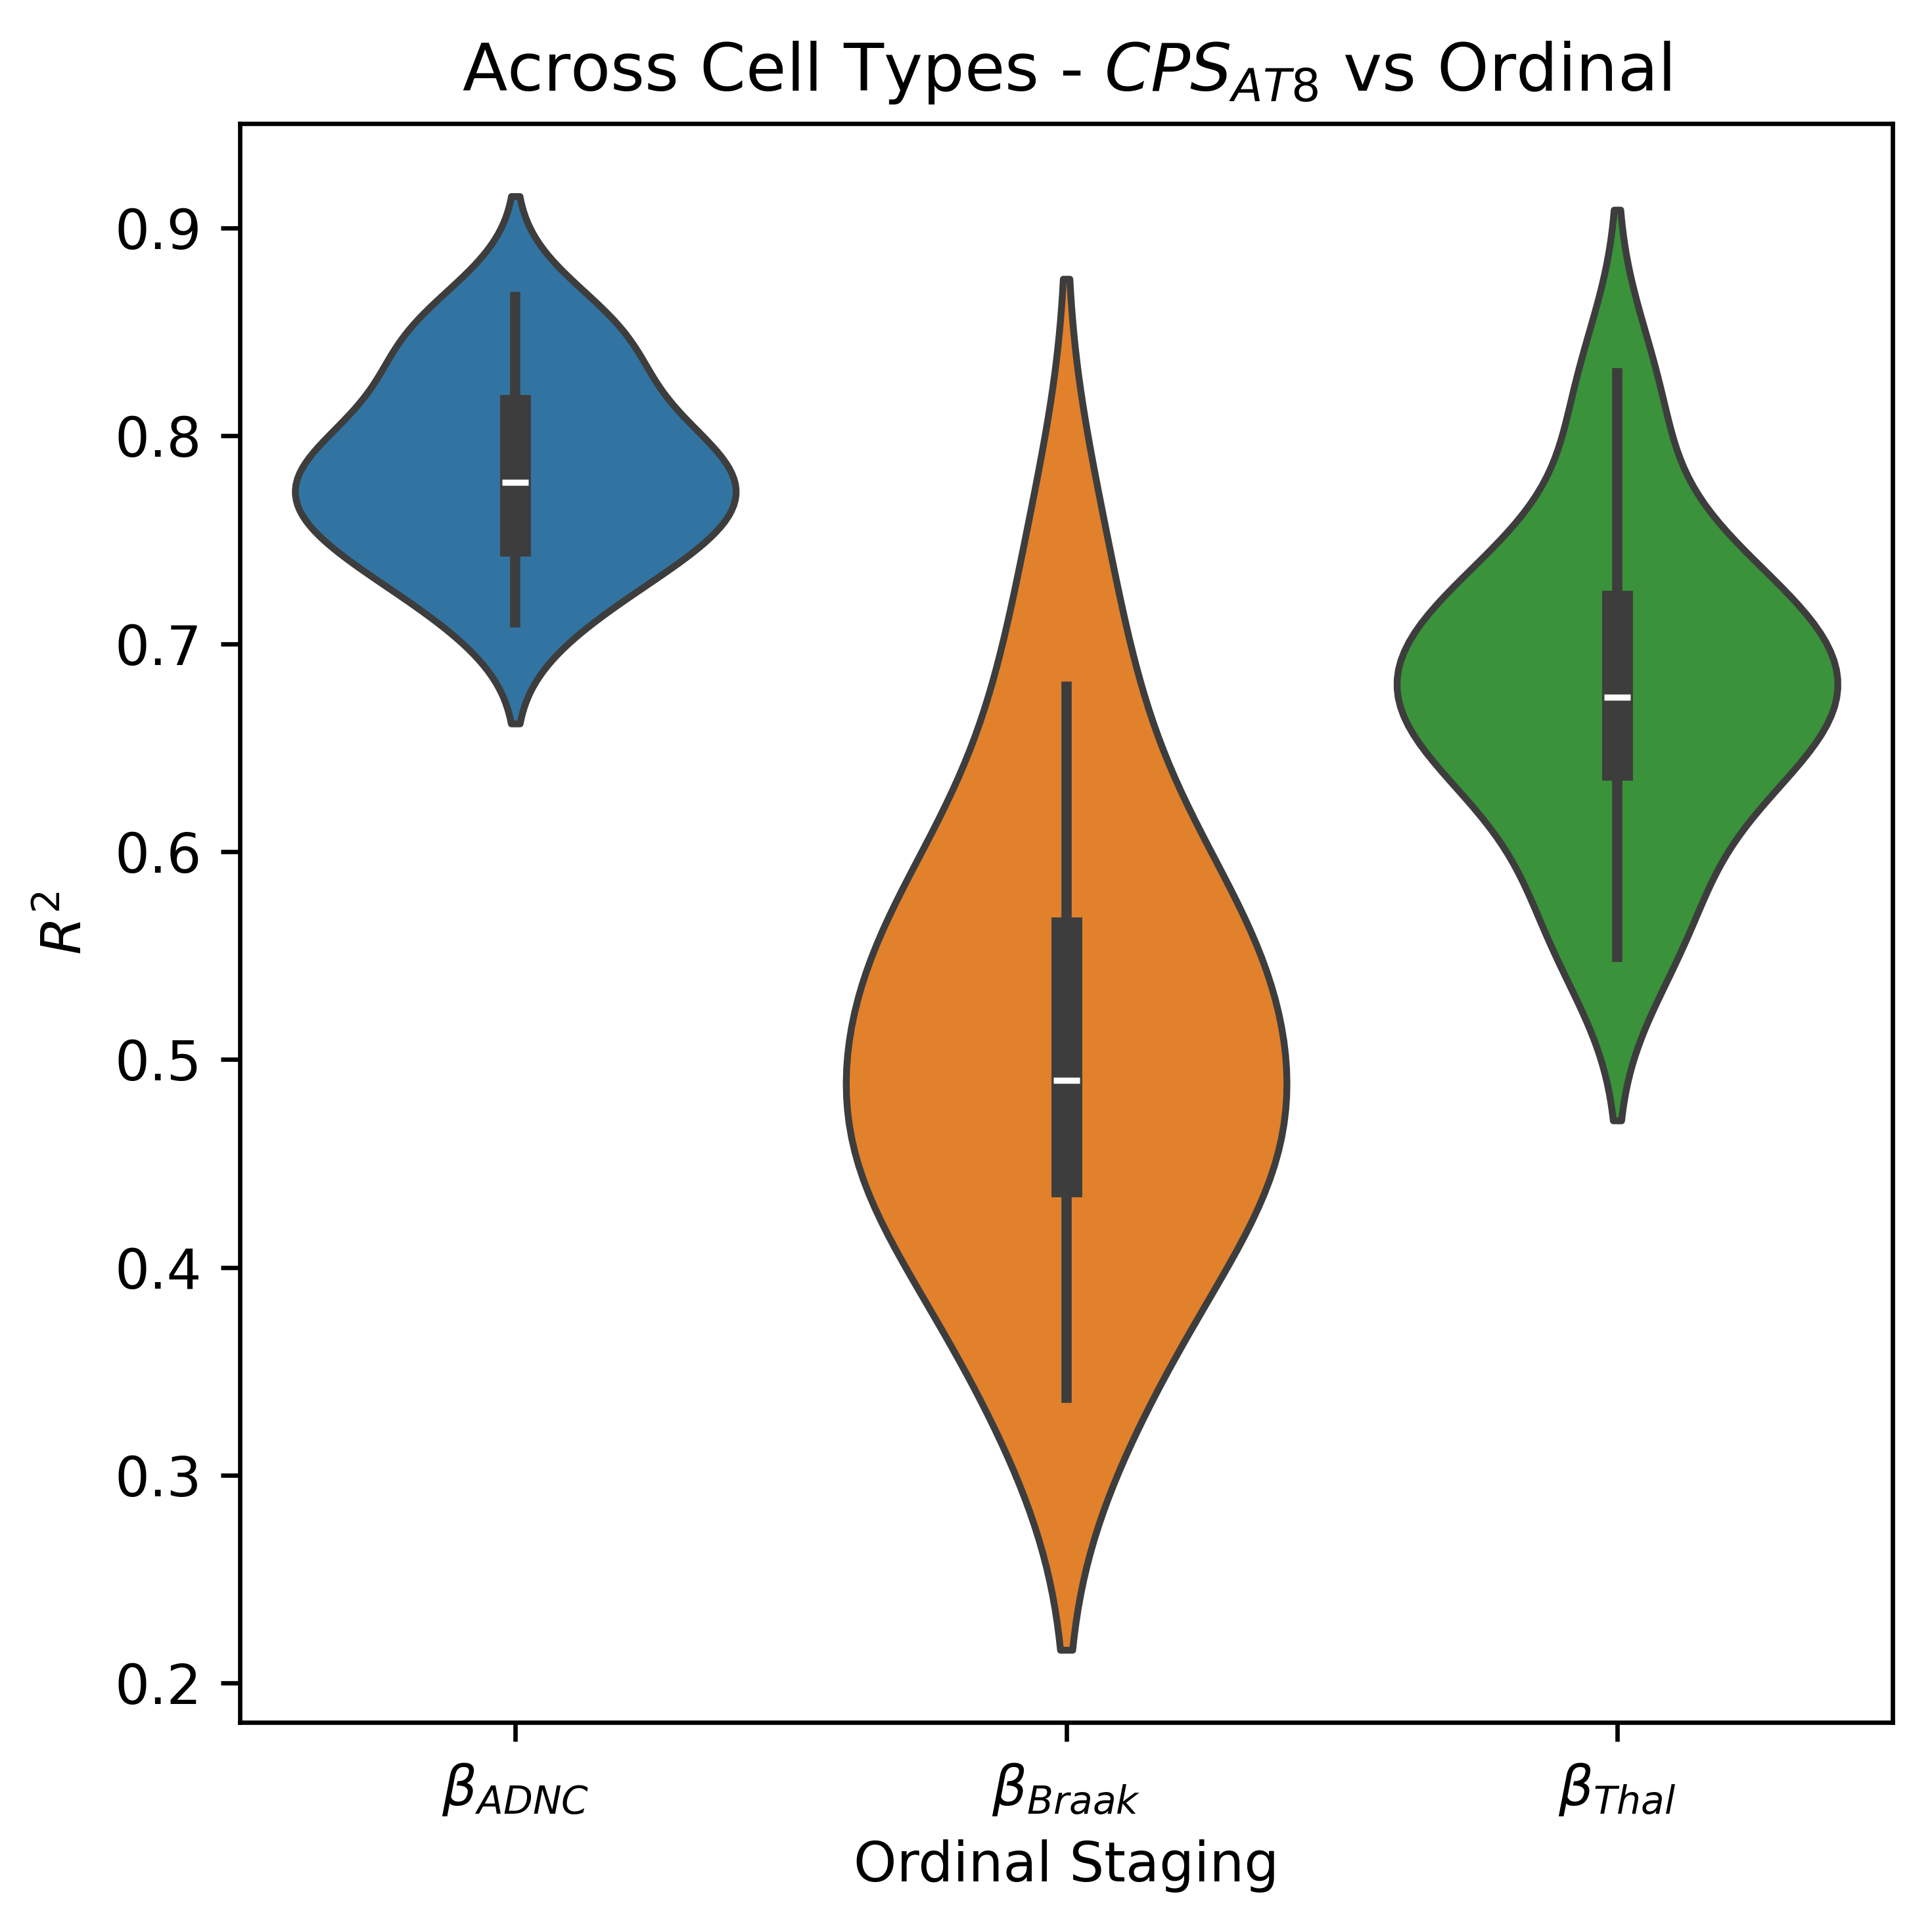

In [16]:
with plt.rc_context({"figure.figsize":(5, 5), 'figure.dpi':600}):
    sns.violinplot(data = corr_df.loc[~corr_df['level_1'].isin([r"$\beta_{CPS\_AT8}$", r"$\beta_{CPS\_6e10}$"]), ['level_1', r"$\beta_{CPS\_AT8}$"]], x = "level_1", y =  r"$\beta_{CPS\_AT8}$",  hue = "level_1",)
    plt.xlabel("Ordinal Staging")
    plt.ylabel(r"$R^2$")
    plt.title("Across Cell Types - $CPS_{AT8}$ vs Ordinal")
    plt.tight_layout()
    plt.savefig("/scratch/SupplementalFigure1_Ordinal_Correlation_Nebula_Violin_AT8.svg")
    plt.show()

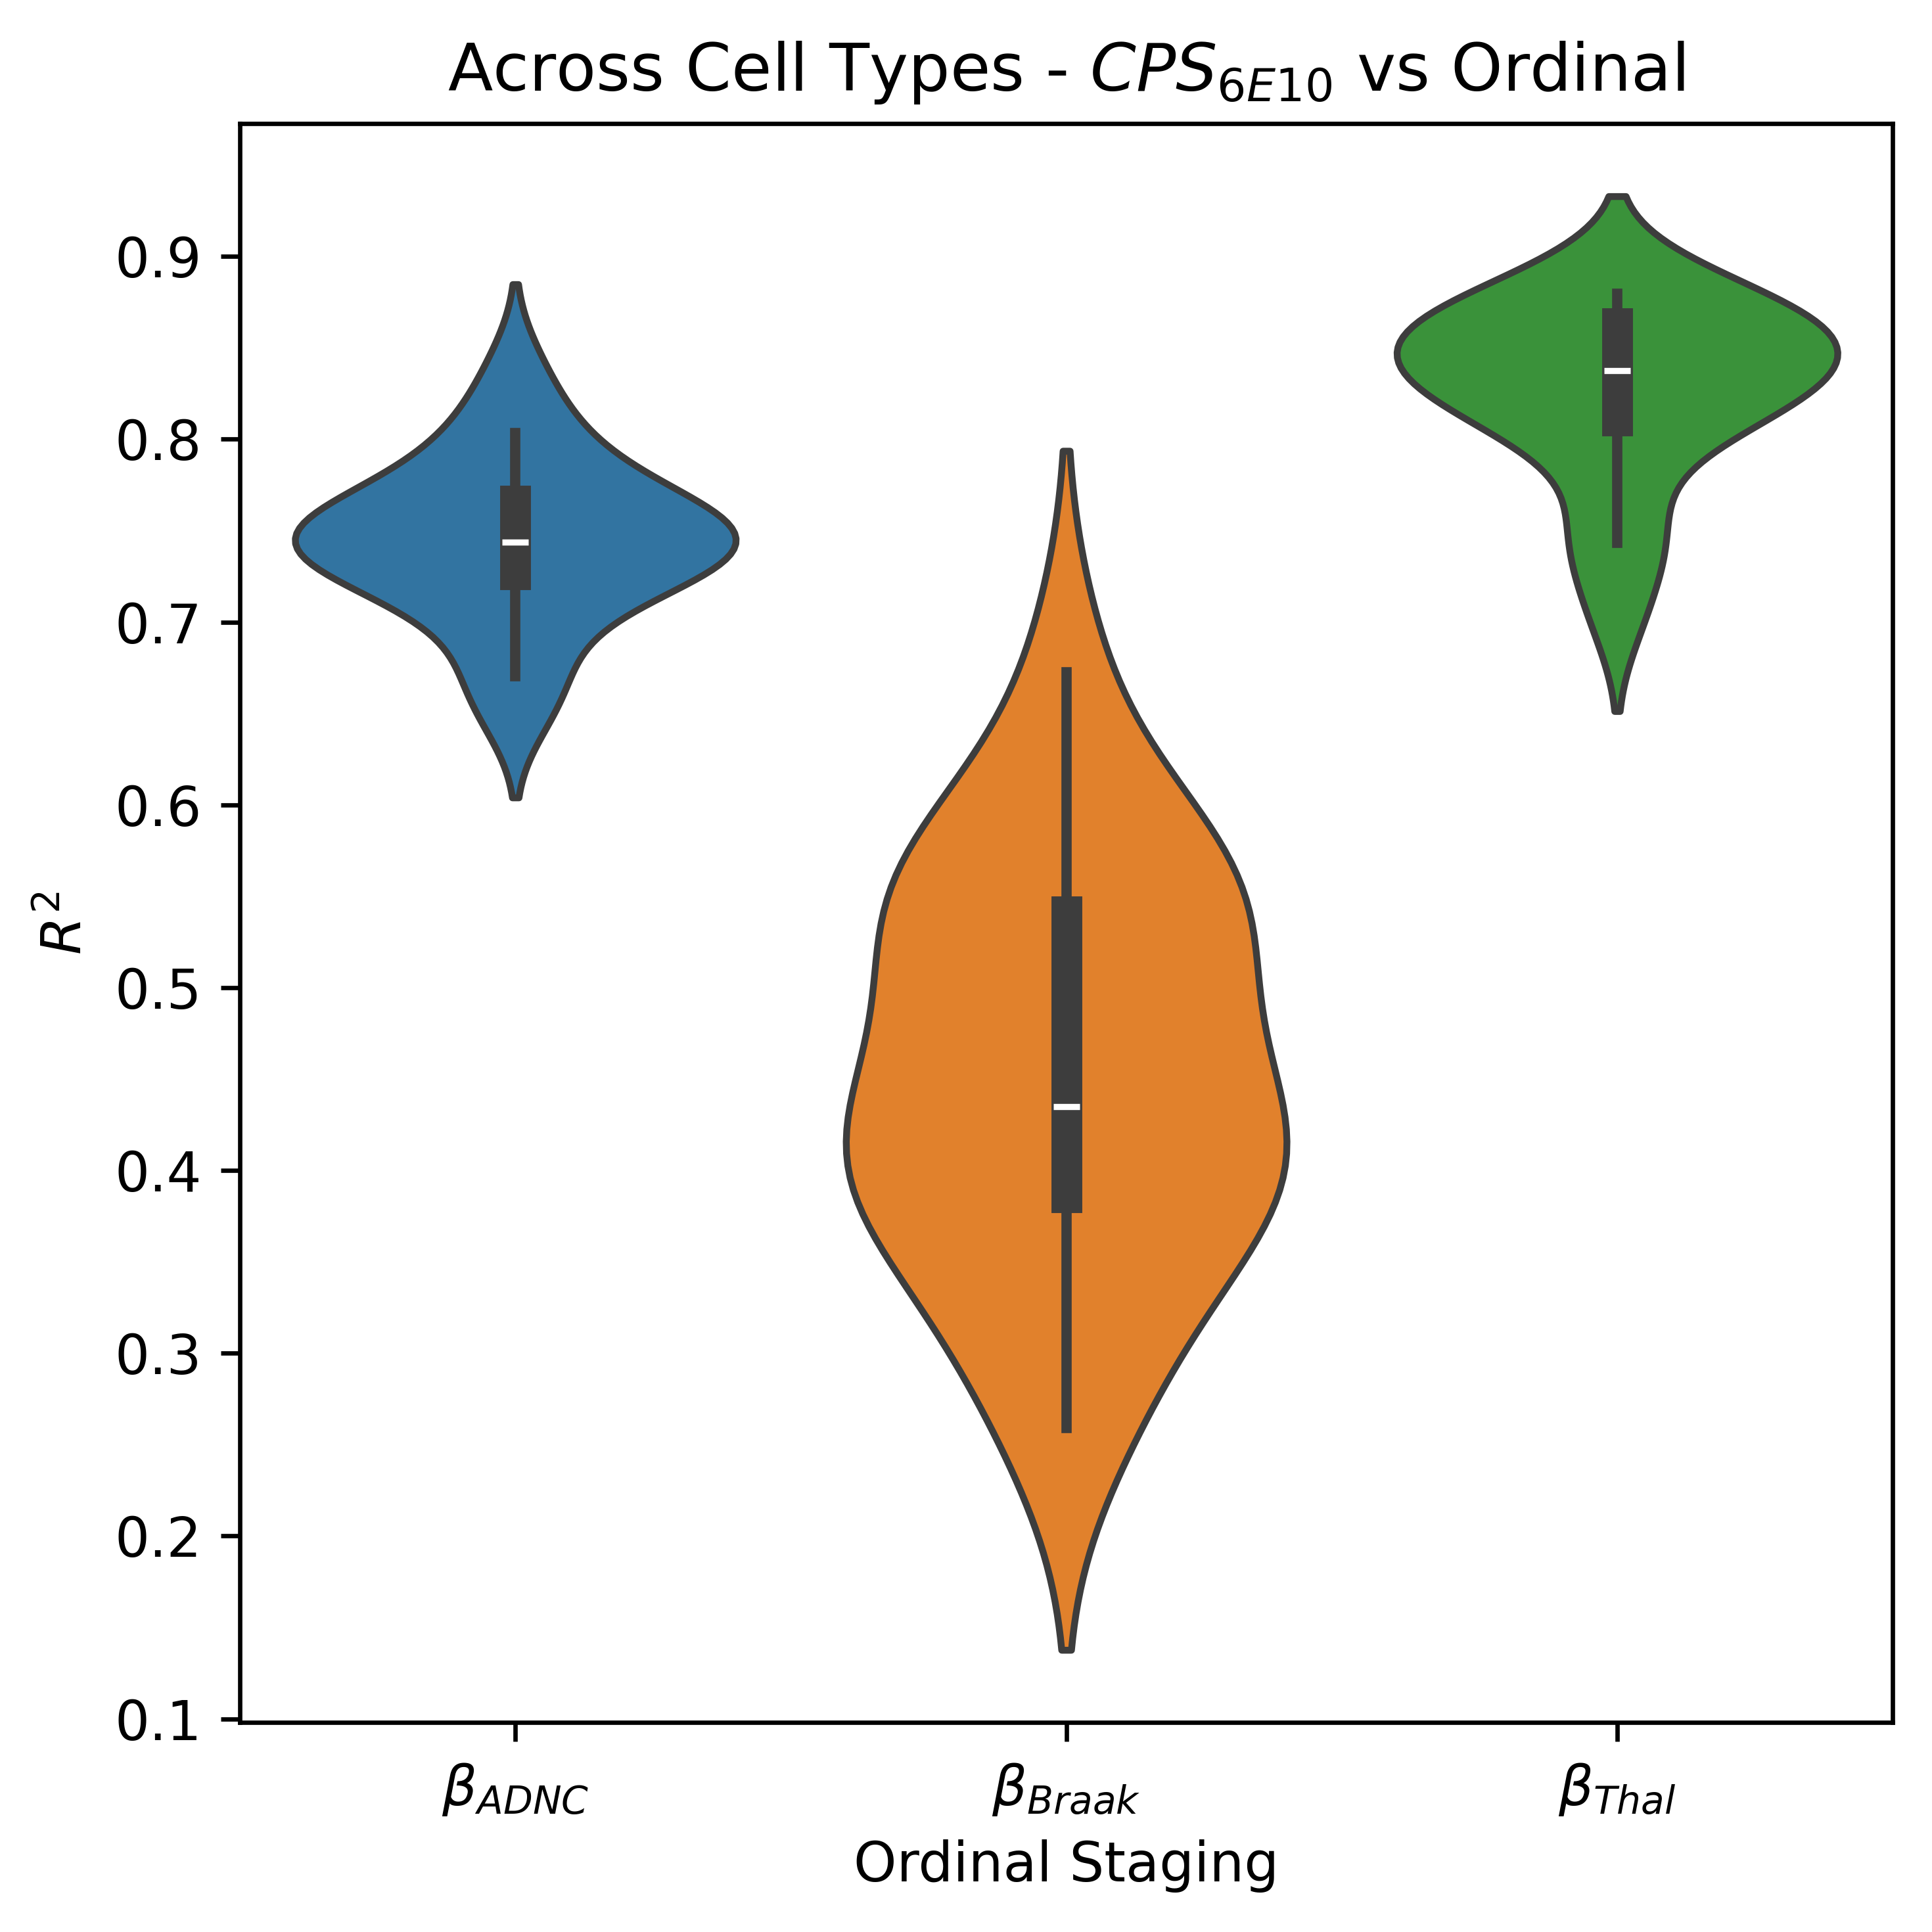

In [17]:
with plt.rc_context({"figure.figsize":(5, 5), 'figure.dpi':600}):
    sns.violinplot(data = corr_df.loc[~corr_df['level_1'].isin([r"$\beta_{CPS\_AT8}$", r"$\beta_{CPS\_6e10}$"]), ['level_1', r"$\beta_{CPS\_6e10}$"]], x = "level_1", y =  r"$\beta_{CPS\_6e10}$",  hue = "level_1",)
    plt.xlabel("Ordinal Staging")
    plt.ylabel(r"$R^2$")
    plt.title("Across Cell Types - $CPS_{6E10}$ vs Ordinal")
    plt.tight_layout()
    plt.savefig("/scratch/SupplementalFigure1_Ordinal_Correlation_Nebula_Violin_6E10.svg")
    plt.show()

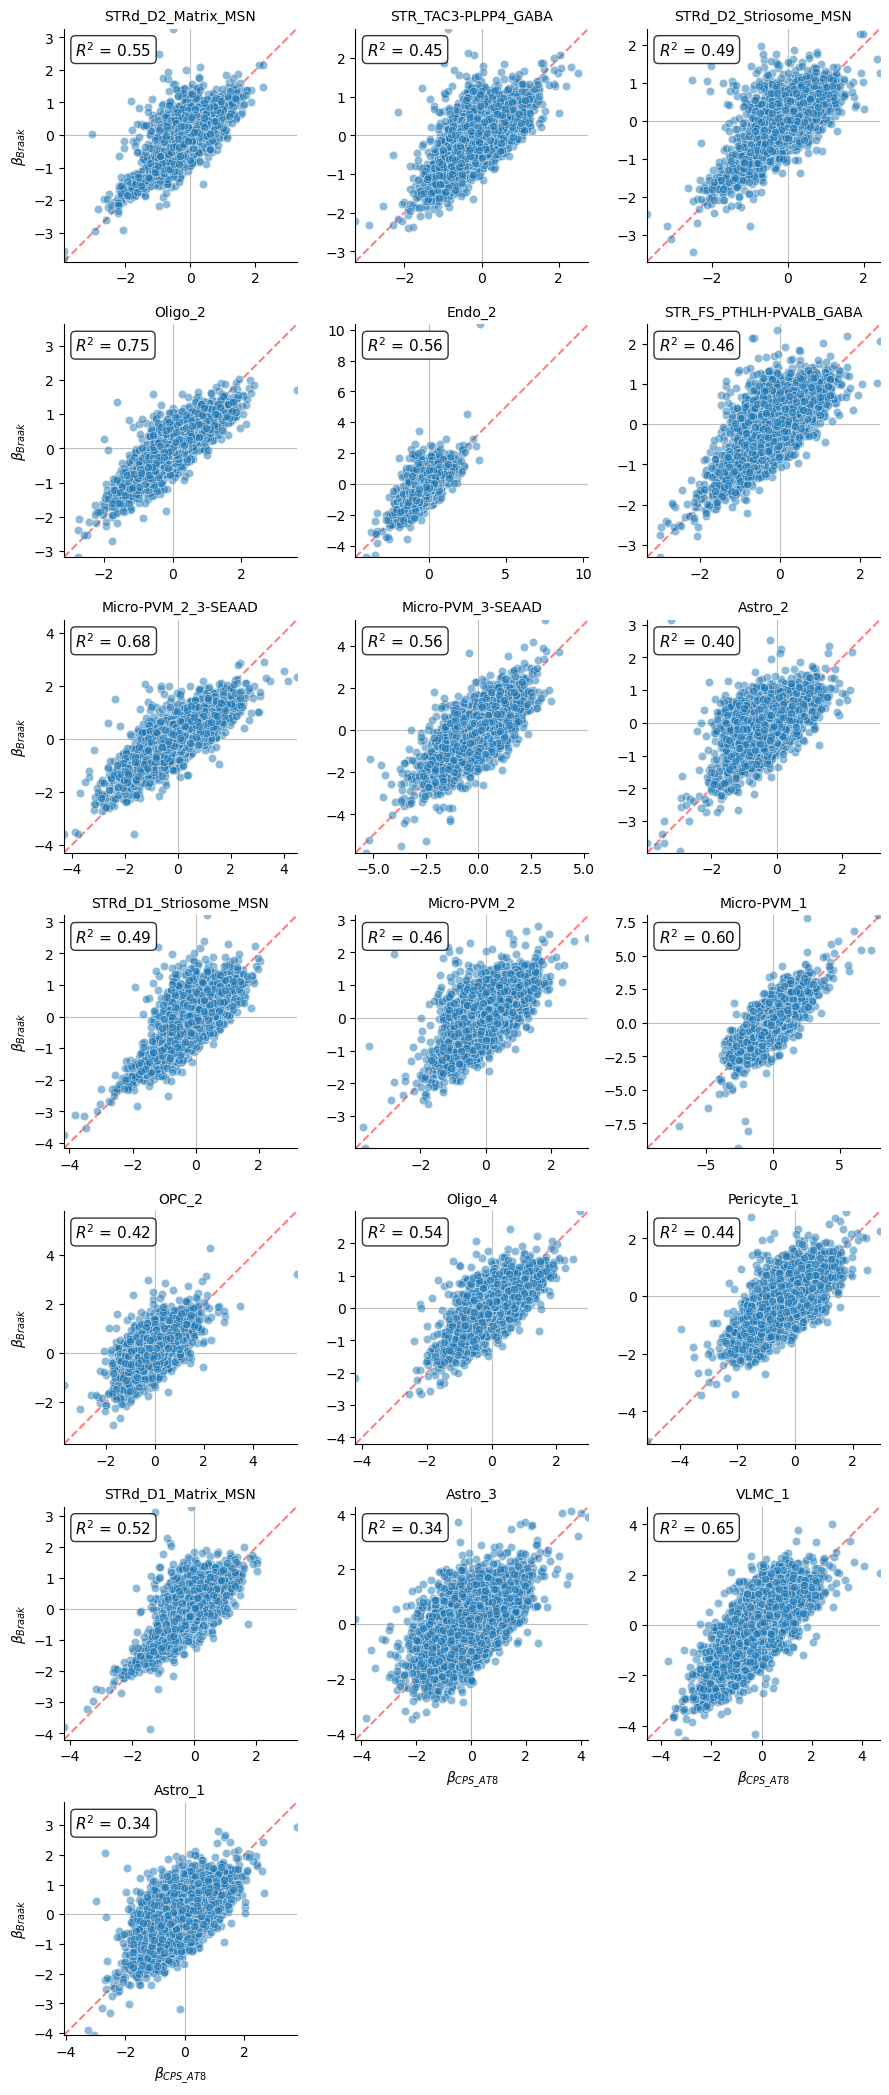

In [18]:
from scipy.stats import pearsonr
def scatter_with_corr(x, y, **kwargs):
    ax = plt.gca()
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]

    sns.scatterplot(x=x, y=y, alpha=0.5, ax=ax)

    # pearson correlation
    r, p = pearsonr(x, y)
    ax.annotate(f'$R^2$ = {r**2:.2f}', xy=(0.05, 0.95), xycoords='axes fraction',
                ha='left', va='top', fontsize=11,
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))

    # equal axes, forced to include the origin
    lo = min(x.min(), y.min(), 0)
    hi = max(x.max(), y.max(), 0)
    lims = [lo, hi]
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')

    # reference lines at the origin
    ax.axhline(0, color='gray', lw=0.8, alpha=0.5, zorder=0)
    ax.axvline(0, color='gray', lw=0.8, alpha=0.5, zorder=0)

    # diagonal reference line
    ax.plot(lims, lims, ls='--', color='red', alpha=0.5, zorder=0)

    
g = sns.FacetGrid(comparison_df.dropna(), col = "Cell Type", col_wrap = 3, sharex = False, sharey = False)
g.map(scatter_with_corr, r"$\beta_{CPS\_AT8}$", r"$\beta_{Braak}$")
g.set_titles("{col_name}")
plt.show()

In [19]:
!pip install adjustText

In [20]:
from adjustText import adjust_text

def scatter_with_corr_ann(x, y, genes_to_label=None, **kwargs):
    ax = plt.gca()
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]

    sns.scatterplot(x=x, y=y, alpha=0.5, ax=ax)

    # pearson correlation
    r, p = pearsonr(x, y)
    ax.annotate(f'$R^2$ = {r**2:.2f}', xy=(0.05, 0.95), xycoords='axes fraction',
                ha='left', va='top', fontsize=11,
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))

    # equal axes, forced to include the origin
    lo = min(x.min(), y.min(), 0)
    hi = max(x.max(), y.max(), 0)
    lims = [lo, hi]
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')

    # reference lines at the origin
    ax.axhline(0, color='gray', lw=0.8, alpha=0.5, zorder=0)
    ax.axvline(0, color='gray', lw=0.8, alpha=0.5, zorder=0)

    # diagonal reference line
    ax.plot(lims, lims, ls='--', color='red', alpha=0.5, zorder=0)

    # label specific genes of interest
    if genes_to_label is not None:
        texts = []
        xs_labeled, ys_labeled = [], []
        for gene in genes_to_label:
            if gene not in x.index:
                continue  # or warnings.warn(f"{gene} not found")
            xi, yi = x.loc[gene], y.loc[gene]
            xs_labeled.append(xi)
            ys_labeled.append(yi)
            texts.append(ax.text(xi, yi, gene, fontsize=9, fontweight='bold', zorder=4))

        if texts:
            ax.scatter(xs_labeled, ys_labeled, color='black', s=20, zorder=3)
            adjust_text(
                texts, ax=ax,
                x=xs_labeled, y=ys_labeled,
                arrowprops=dict(arrowstyle='-', color='black', lw=0.5, alpha=0.7),
            )

    return ax


Saved: /scratch/SupplmentalFig1_STR_FS_PTHLH-PVALB_GABA_BraakvCPS.png


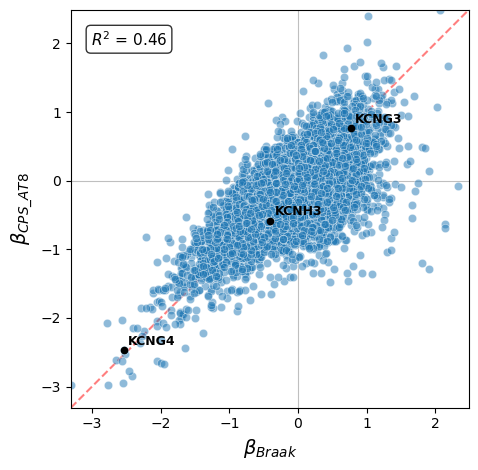

In [42]:
cell_type = 'STR_FS_PTHLH-PVALB_GABA'
plot_df = comparison_df[comparison_df['Cell Type'] == cell_type]
plot_df.index = plot_df.index.map(lambda x: x.split("_")[-1])
fig = plt.figure()
ax = scatter_with_corr_ann(y = plot_df[r"$\beta_{CPS\_AT8}$"], x= plot_df[r"$\beta_{Braak}$"], genes_to_label = ['KCNH3', 'KCNG3', 'KCNG4'])
# ax.set_title(cell_type)
plt.xlabel(ax.get_xlabel(), fontsize = 14)
plt.ylabel(ax.get_ylabel(), fontsize = 14)
plt.tight_layout()
save_figure(fig, f"/scratch/SupplmentalFig1_{cell_type}_BraakvCPS", formats = ["png"], dpi = 600)
plt.show()
plt.close()

Saved: /scratch/SupplmentalFig1_STR_FS_PTHLH-PVALB_GABA_ThalvCPS.png


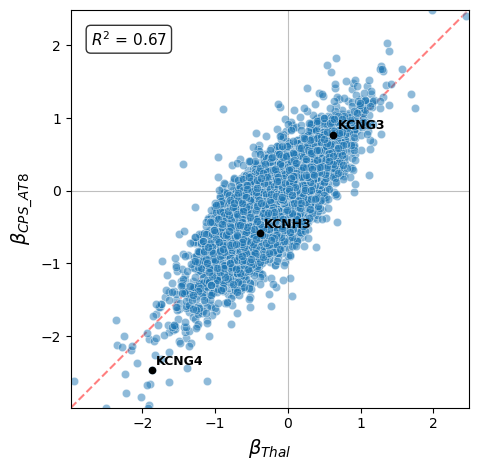

In [43]:
cell_type = 'STR_FS_PTHLH-PVALB_GABA'
plot_df = comparison_df[comparison_df['Cell Type'] == cell_type]
plot_df.index = plot_df.index.map(lambda x: x.split("_")[-1])
fig = plt.figure()
ax = scatter_with_corr_ann(y= plot_df[r"$\beta_{CPS\_AT8}$"], x = plot_df[r"$\beta_{Thal}$"], genes_to_label = ['KCNH3', 'KCNG3', 'KCNG4'])
#ax.set_title(cell_type)
plt.xlabel(ax.get_xlabel(), fontsize = 14)
plt.ylabel(ax.get_ylabel(), fontsize = 14)
plt.tight_layout()
save_figure(fig, f"/scratch/SupplmentalFig1_{cell_type}_ThalvCPS", formats = ["png"], dpi = 600)
plt.show()
plt.close()

Saved: /scratch/SupplmentalFig1_Micro-PVM_2_3-SEAAD_ThalvCPS.png


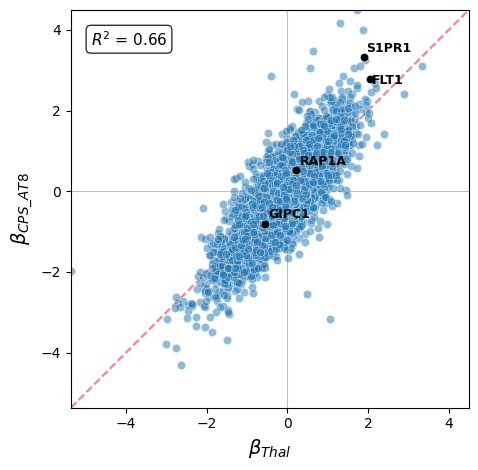

In [44]:
cell_type =  "Micro-PVM_2_3-SEAAD"
genes_to_label = ['FLT1', 'GIPC1', 'RAP1A', 'S1PR1']
plot_df = comparison_df[comparison_df['Cell Type'] == cell_type]
plot_df.index = plot_df.index.map(lambda x: x.split("_")[-1])
fig = plt.figure()
ax = scatter_with_corr_ann(y = plot_df[r"$\beta_{CPS\_AT8}$"], x = plot_df[r"$\beta_{Thal}$"], genes_to_label = genes_to_label)
#ax.set_title(cell_type)
plt.xlabel(ax.get_xlabel(), fontsize = 14)
plt.ylabel(ax.get_ylabel(), fontsize = 14)
plt.tight_layout()
save_figure(fig, f"/scratch/SupplmentalFig1_{cell_type}_ThalvCPS", formats = ["png"], dpi = 600)
plt.show()
plt.close()

Saved: /scratch/SupplmentalFig1_Micro-PVM_2_3-SEAAD_BraakvCPS.png


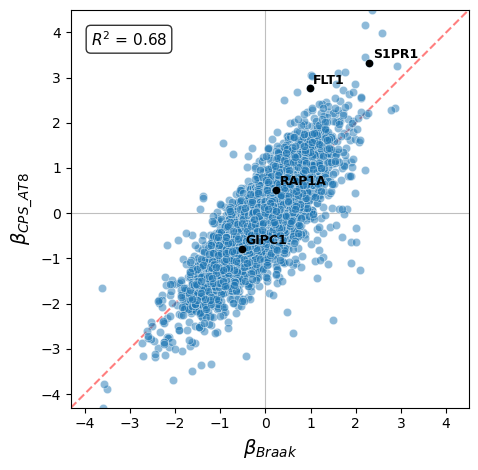

In [45]:
cell_type =  "Micro-PVM_2_3-SEAAD"
genes_to_label = ['FLT1', 'GIPC1', 'RAP1A', 'S1PR1']
plot_df = comparison_df[comparison_df['Cell Type'] == cell_type]
plot_df.index = plot_df.index.map(lambda x: x.split("_")[-1])
fig = plt.figure()
ax = scatter_with_corr_ann(y = plot_df[r"$\beta_{CPS\_AT8}$"], x = plot_df[r"$\beta_{Braak}$"], genes_to_label = genes_to_label)
plt.xlabel(ax.get_xlabel(), fontsize = 14)
plt.ylabel(ax.get_ylabel(), fontsize = 14)
plt.tight_layout()
save_figure(fig, f"/scratch/SupplmentalFig1_{cell_type}_BraakvCPS", formats = ["png"], dpi = 600)
plt.show()
plt.close()

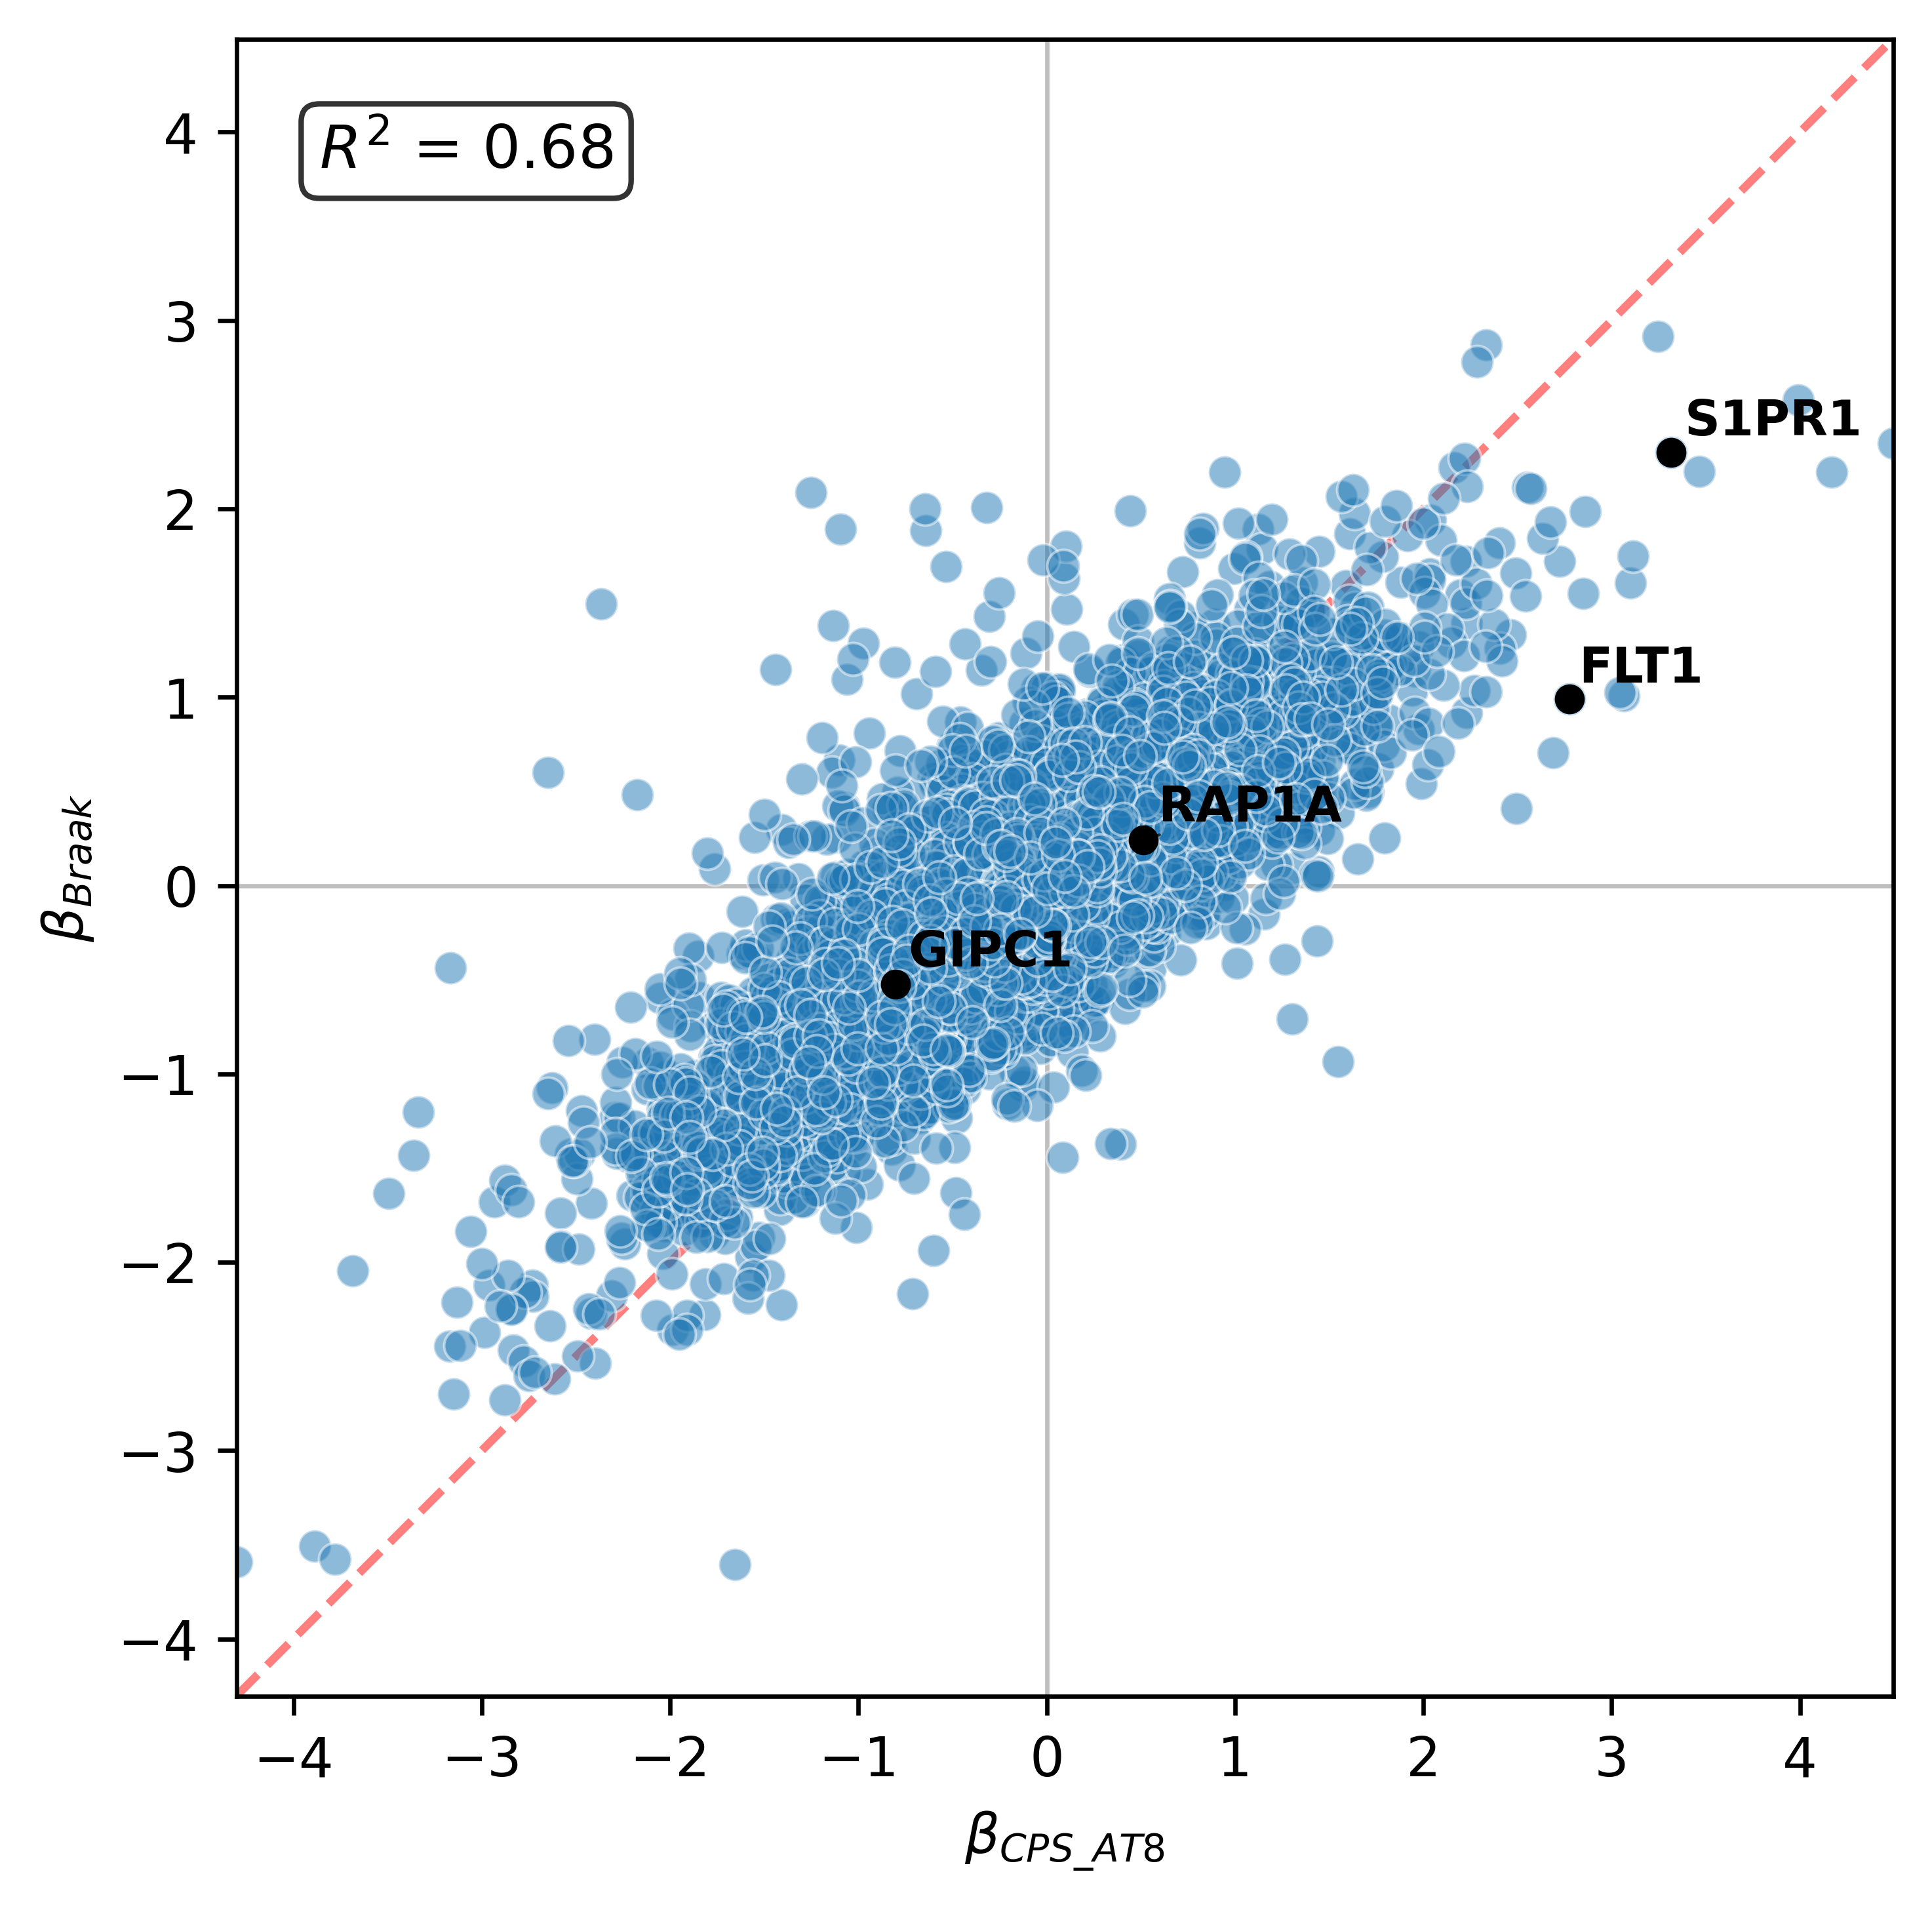

In [24]:
cell_type =  "Micro-PVM_2_3-SEAAD"
with plt.rc_context({"figure.figsize":(5, 5), 'figure.dpi':600}):
    genes_to_label = ['FLT1', 'GIPC1', 'RAP1A', 'S1PR1']
    plot_df = comparison_df[comparison_df['Cell Type'] == cell_type]
    plot_df.index = plot_df.index.map(lambda x: x.split("_")[-1])
    fig = plt.figure()
    scatter_with_corr_ann(plot_df[r"$\beta_{CPS\_AT8}$"], plot_df[r"$\beta_{Braak}$"], genes_to_label = genes_to_label)
    # save_figure(fig, f"/scratch/SupplmentalFig1_{cell_type}_BraakvCPS", formats = ["png"], dpi = 600)
    plt.tight_layout()
    plt.show()

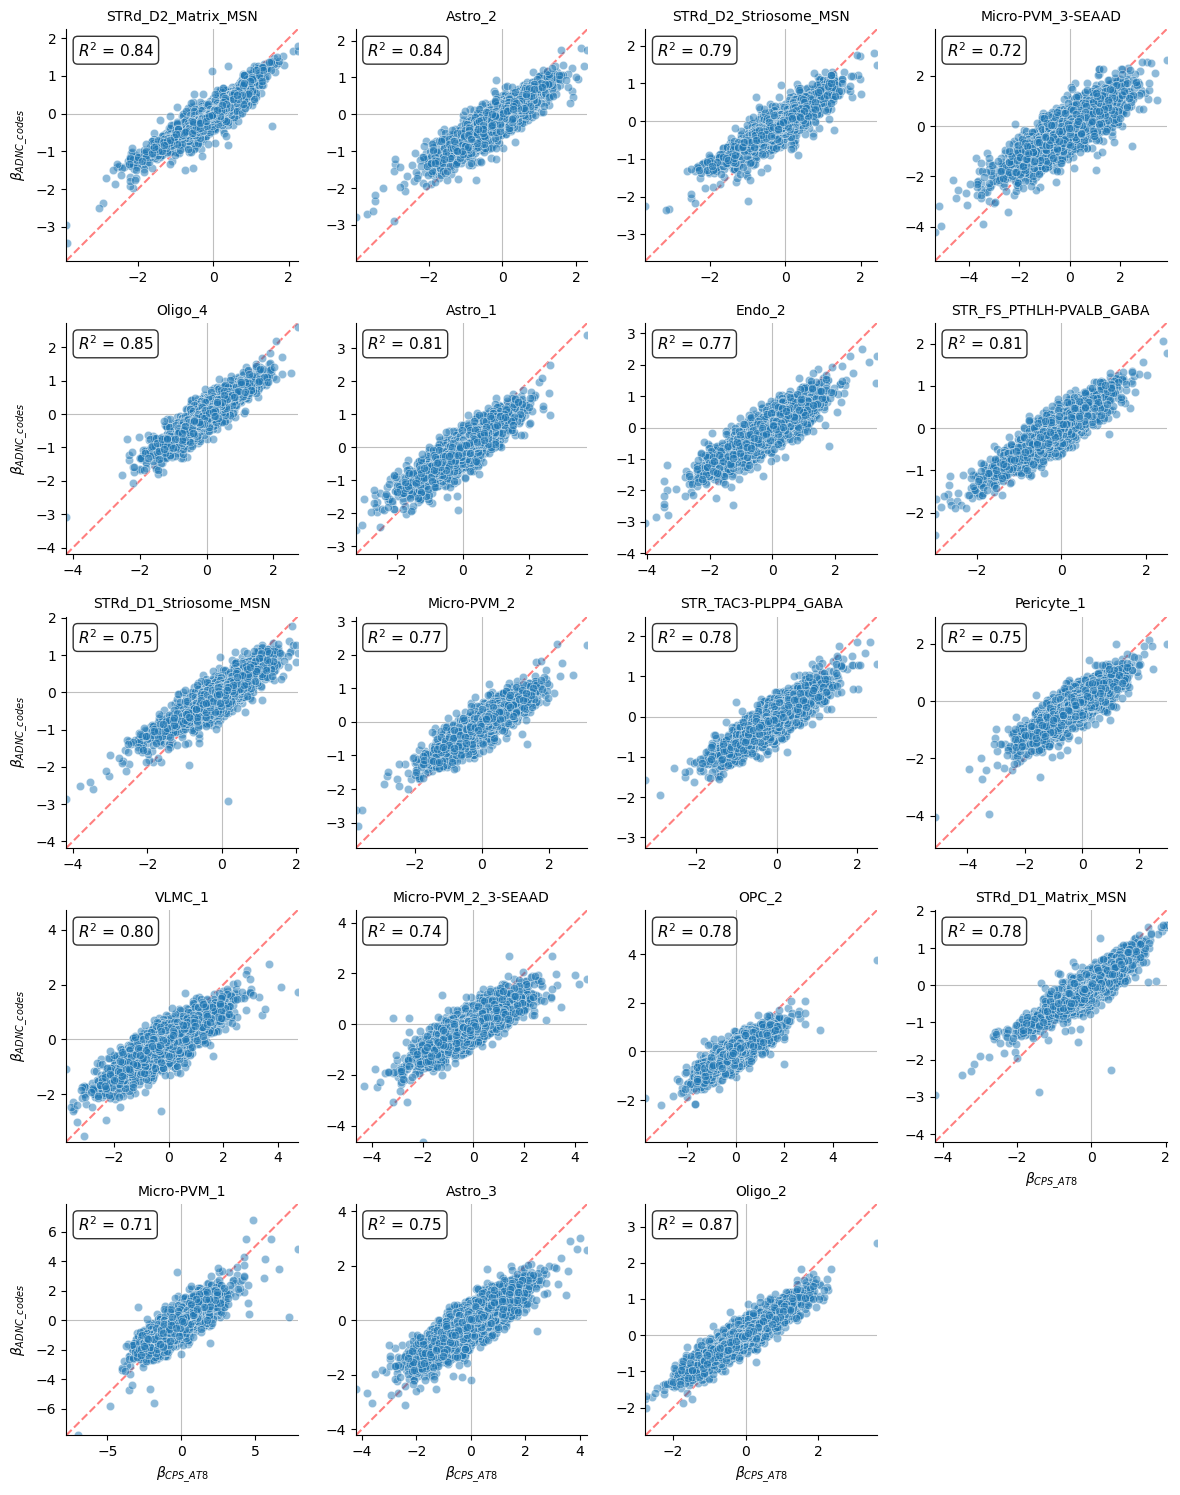

In [23]:
g = sns.FacetGrid(comparison_df.dropna(), col = "Cell Type", col_wrap = 4, sharex = False, sharey = False)
g.map(scatter_with_corr, r"$\beta_{CPS\_AT8}$", r"$\beta_{ADNC\_codes}$")
g.set_titles("{col_name}")
plt.show()

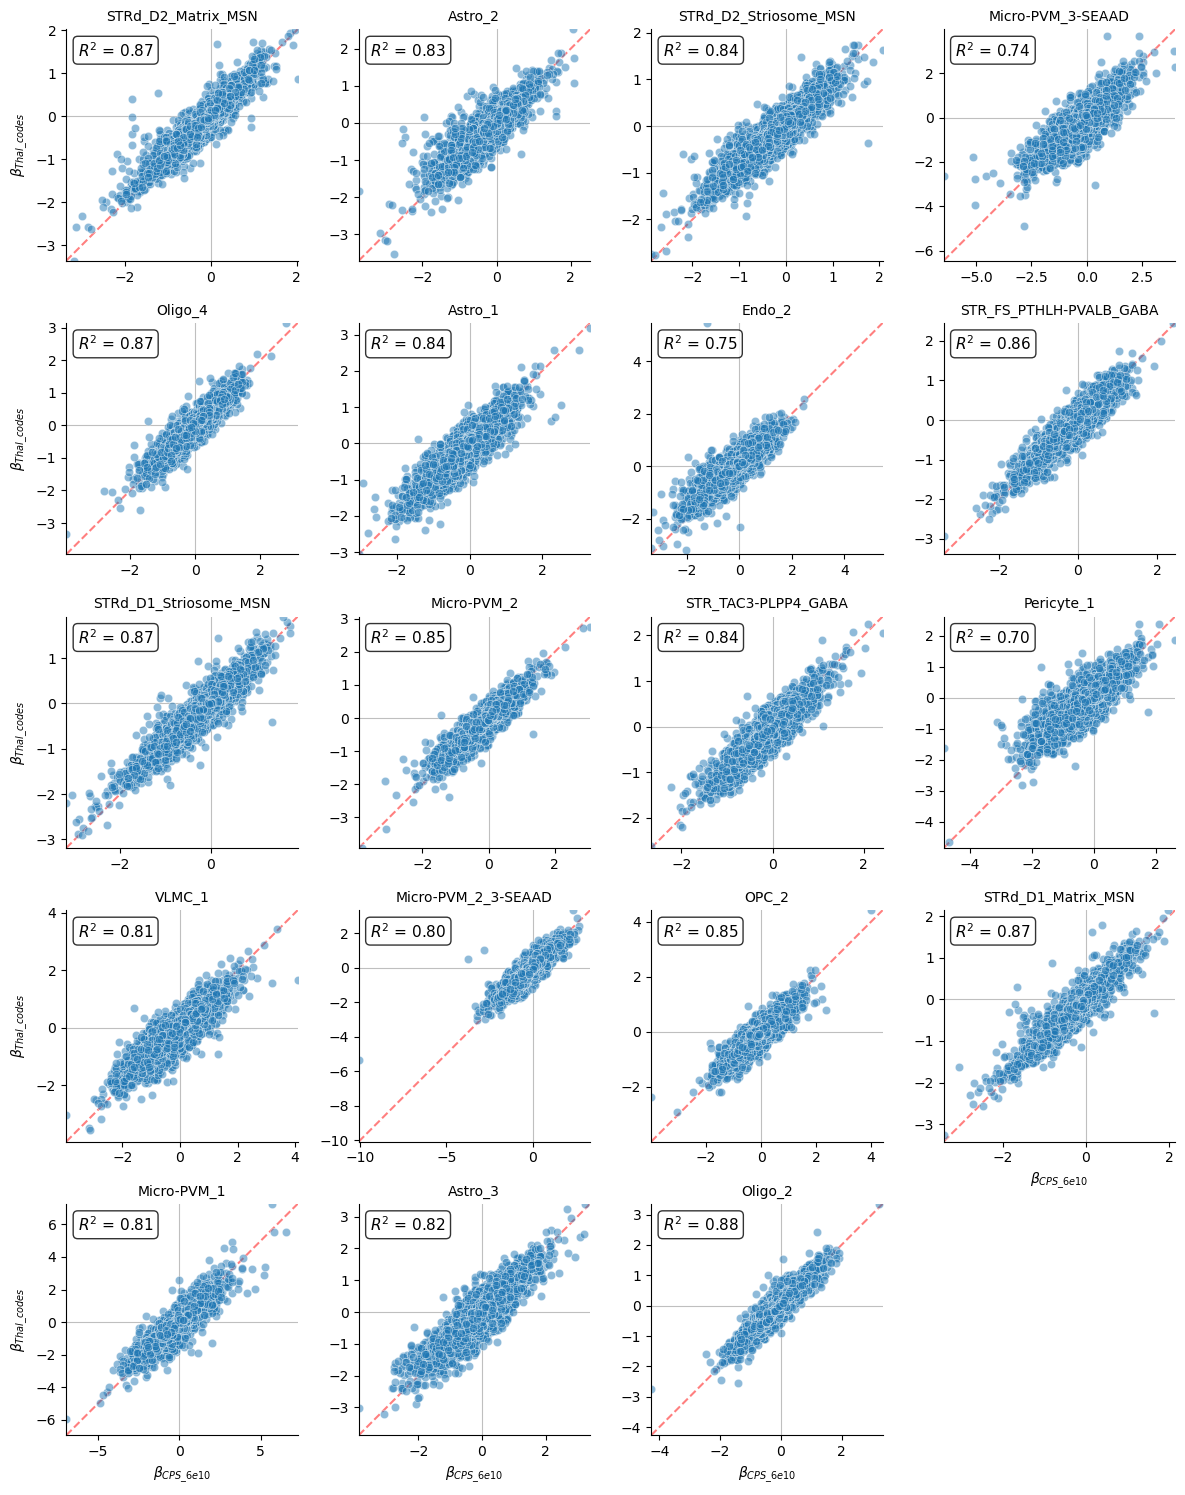

In [24]:

g = sns.FacetGrid(comparison_df.dropna(), col = "Cell Type", col_wrap = 4, sharex = False, sharey = False)
g.map(scatter_with_corr, r"$\beta_{CPS\_6e10}$", r"$\beta_{Thal\_codes}$")
g.set_titles("{col_name}")
plt.show()

In [23]:
comparison_dict = {}
index_set = set()
for path, df in df_dict.items():
    values = df_dict[path][f'logFC_{path}'].dropna()
    if not index_set:
        index_set = set(values.index) | index_set
    else:
        index_set = set(values.index) & index_set

index_list = list(index_set)
comparison_dict = {fr"$FDR_{{{path.replace("_", "\_")}}}$":df.loc[index_list, f'fdr_p_{path}'] for path, df in df_dict.items()}
comparison_df = pd.DataFrame(comparison_dict)
comparison_df["gene"] = comparison_df.index.map(lambda x: x.split("_")[-1])
comparison_df["Cell Type"] = comparison_df.index.map(lambda x: "_".join(x.split("_")[:-1]))
comparison_df

<>:11: SyntaxWarning: invalid escape sequence '\_'
<>:11: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_4639/3786845613.py:11: SyntaxWarning: invalid escape sequence '\_'
  comparison_dict = {fr"$FDR_{{{path.replace("_", "\_")}}}$":df.loc[index_list, f'fdr_p_{path}'] for path, df in df_dict.items()}


,$FDR_{CPS\_AT8}$,$FDR_{CPS\_6e10}$,$FDR_{ADNC\_codes1.0}$,$FDR_{Braak\_codes}$,$FDR_{Thal\_codes}$,gene,Cell Type
Oligo_2_IGLL1,0.617104,0.635227,0.640177,0.755759,0.374711,IGLL1,Oligo_2
Micro-PVM_2_IRGQ,0.904153,0.999488,0.832098,0.975749,0.969014,IRGQ,Micro-PVM_2
STR_FS_PTHLH-PVALB_GABA_AC110992.1,0.981931,0.972215,0.953110,0.261360,0.752164,AC110992.1,STR_FS_PTHLH-PVALB_GABA
STRd_D1_Matrix_MSN_LINC00850,0.964431,0.537351,0.946878,0.676615,0.505614,LINC00850,STRd_D1_Matrix_MSN
STRd_D2_Matrix_MSN_AC009560.4,0.924820,0.607737,0.952235,0.535020,0.581785,AC009560.4,STRd_D2_Matrix_MSN
...,...,...,...,...,...,...,...
Astro_2_CKMT1B,0.478224,0.317326,0.629111,0.467103,0.293508,CKMT1B,Astro_2
OPC_2_MTHFS,0.817529,0.929247,0.974838,0.448555,0.724904,MTHFS,OPC_2
STRd_D2_Striosome_MSN_GBGT1,0.916187,0.792297,0.999922,0.803498,0.720586,GBGT1,STRd_D2_Striosome_MSN
VLMC_1_TSPAN17,0.166244,0.298090,0.022032,0.000975,0.168191,TSPAN17,VLMC_1


<>:34: SyntaxWarning: invalid escape sequence '\_'
<>:34: SyntaxWarning: invalid escape sequence '\_'
<>:34: SyntaxWarning: invalid escape sequence '\_'
<>:34: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_4639/881005445.py:34: SyntaxWarning: invalid escape sequence '\_'
  g.map(scatter_with_corr, "$FDR_{CPS\_AT8}$", "$FDR_{Braak\_codes}$")
/tmp/ipykernel_4639/881005445.py:34: SyntaxWarning: invalid escape sequence '\_'
  g.map(scatter_with_corr, "$FDR_{CPS\_AT8}$", "$FDR_{Braak\_codes}$")


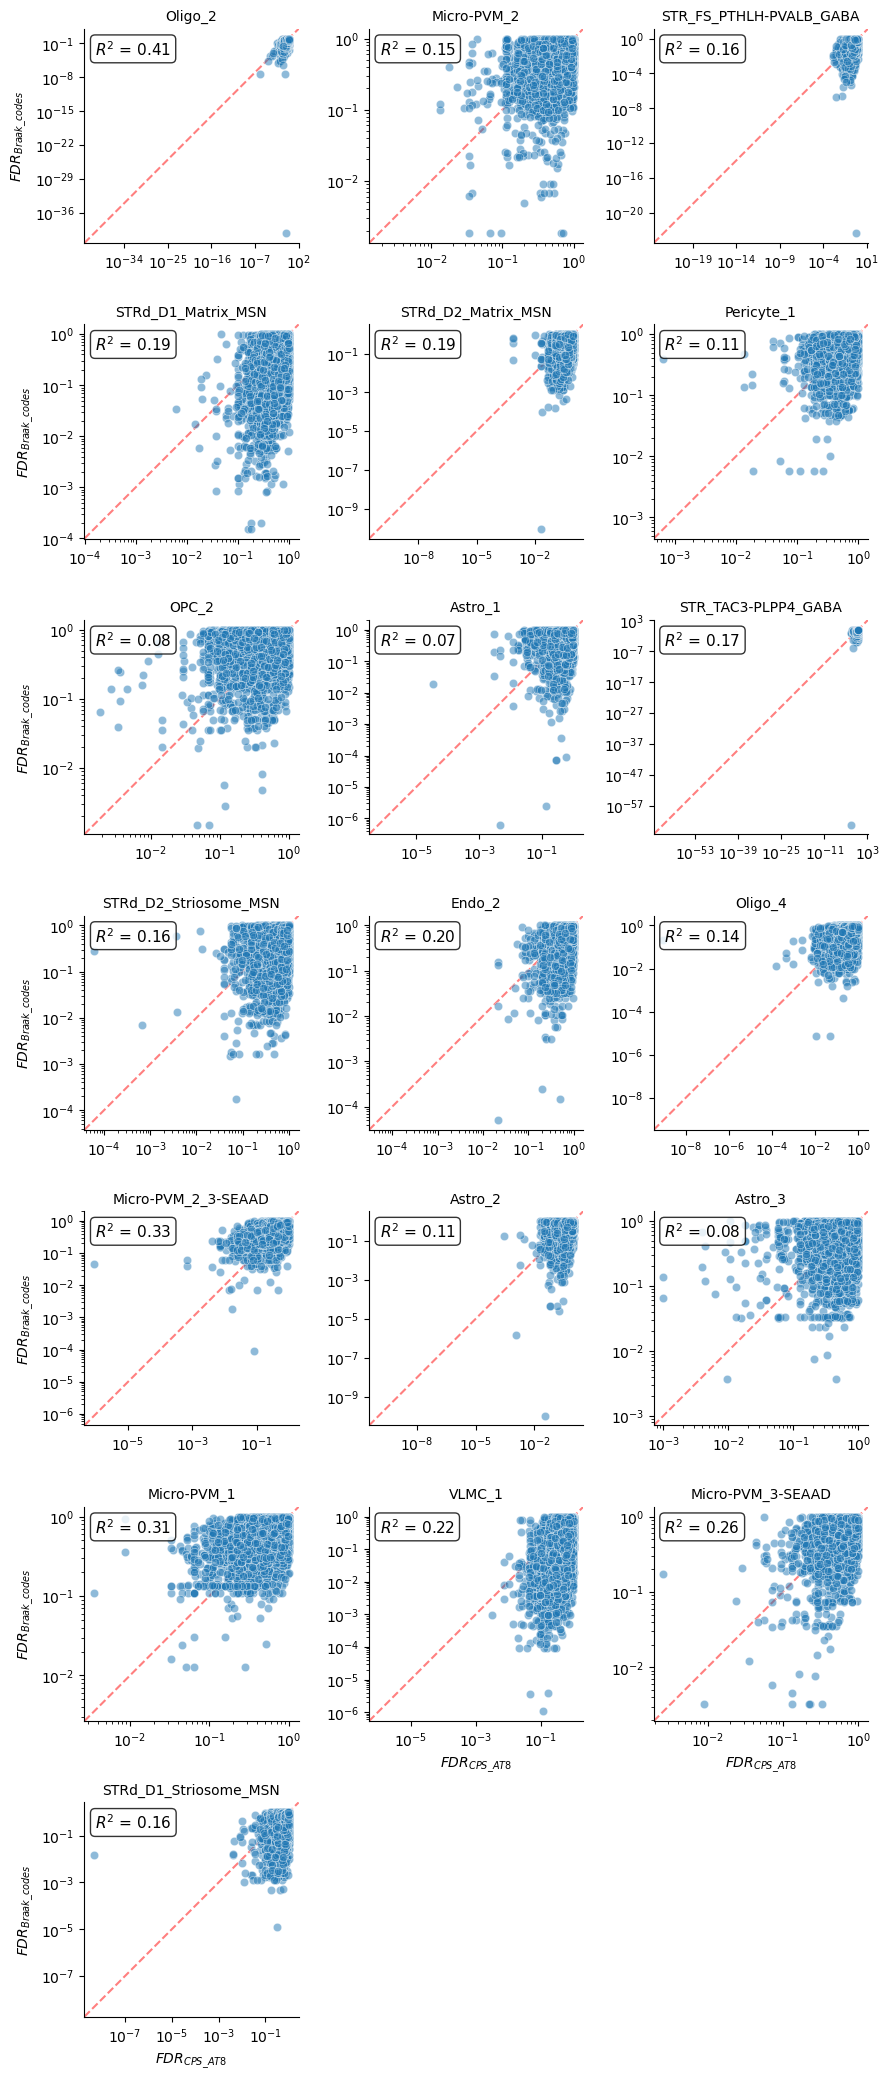

In [26]:
def scatter_with_corr(x, y, **kwargs):
    ax = plt.gca()
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]

    sns.scatterplot(x=x, y=y, alpha=0.5, ax=ax)

    # pearson correlation
    r, p = pearsonr(x, y)
    ax.annotate(f'$R^2$ = {r**2:.2f}', xy=(0.05, 0.95), xycoords='axes fraction',
                ha='left', va='top', fontsize=11,
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))

    # set log scale
    ax.set_xscale("log")
    ax.set_yscale("log")

    # equal axes, forced to include the origin
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    lims = [min(xmin, ymin), max(xmax, ymax)]
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')

    # reference lines at the origin
    ax.axhline(0, color='gray', lw=0.8, alpha=0.5, zorder=0)
    ax.axvline(0, color='gray', lw=0.8, alpha=0.5, zorder=0)

    # diagonal reference line
    ax.plot(lims, lims, ls='--', color='red', alpha=0.5, zorder=0)

g = sns.FacetGrid(comparison_df.dropna(), col = "Cell Type", col_wrap = 3, sharex = False, sharey = False)
g.map(scatter_with_corr, "$FDR_{CPS\_AT8}$", "$FDR_{Braak\_codes}$")
g.set_titles("{col_name}")
plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\_'
<>:2: SyntaxWarning: invalid escape sequence '\_'
<>:2: SyntaxWarning: invalid escape sequence '\_'
<>:2: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_4639/3534104166.py:2: SyntaxWarning: invalid escape sequence '\_'
  g.map(scatter_with_corr, "$FDR_{CPS\_6e10}$", "$FDR_{Thal\_codes}$")
/tmp/ipykernel_4639/3534104166.py:2: SyntaxWarning: invalid escape sequence '\_'
  g.map(scatter_with_corr, "$FDR_{CPS\_6e10}$", "$FDR_{Thal\_codes}$")


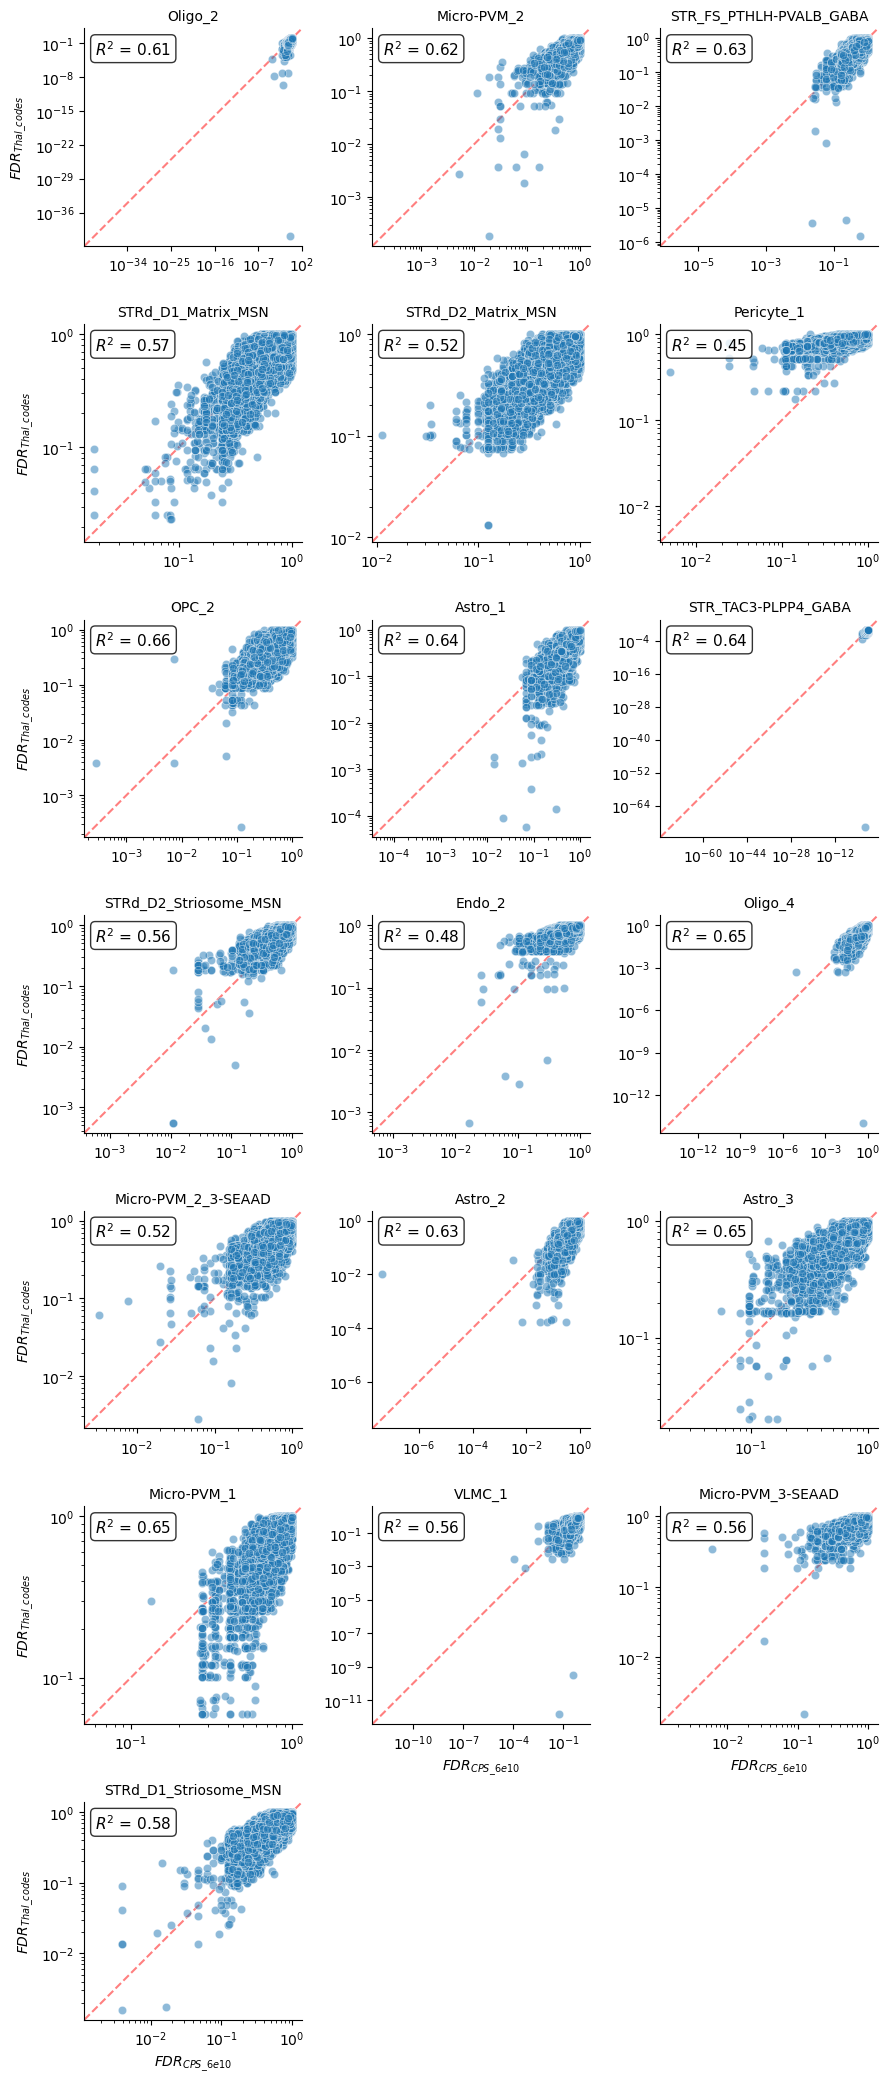

In [27]:
g = sns.FacetGrid(comparison_df.dropna(), col = "Cell Type", col_wrap = 3, sharex = False, sharey = False)
g.map(scatter_with_corr, "$FDR_{CPS\_6e10}$", "$FDR_{Thal\_codes}$")
g.set_titles("{col_name}")
plt.show()